---
# **SEMTM0016 Coursework - Artificial Intelligence in Robotics Report**
---

## **1. Introduction**

This report presents a comprehensive understanding of Machine Learning (ML) models, specifically focusing on the implementation, optimization.It also critical evaluate of different algorithms such as **Supervised (SL)**, **Unsupervised (USL)**, and **Reinforcement Learning (RL)**. 

The objective is to demonstrate technical proficiency in **Algorithm Selection**, where specific algorithms are justified through data analysis and the underlying project requirements, and **Integrated Evaluation** where different ML models are assessed not as isolated components but as interconnected stages within a unified data pipeline that collectively determine system performance.

To demonstrate these competencies in a realistic context, this project adopts a **narrative-driven approach** to machine learning, where a gamified ***Hero Bot and the MazeDungeon*** is mapped to a imaginary ***Industrial Operational Technology (OT) framework***.

### **1.1 Narrative -** Smart Factory Integration

**Problem Statement**

In an automated industrial facility, continuous monitoring of different types of robotic assets is important and yet challenging. The core problem addressed in this pipeline is the development of an autonomous inspection system capable of physical navigation and multi-modal data validation.

The checking agent will autonomously navigate the complex, *maze-like layout of the factory floor* to locate different robots dynamically spawned at various locations. Once an asset location is reached, the system must validate robot telemetry and classify visual images against baseline standards. This ensures that every robot on the floor is operating safely and accurately, bridging the gap between physical navigation and data-driven oversight.

To solve this inspection challenge, the project integrates three distinct machine learning algorithm instead operating in isolation. These models will converge whenever the checking agent encounters a spawned robot on the factory floor:
1. **The Navigator (Reinforcement Learning) -** The physical layout of the facility is modeled as a complex maze. The RL agent's primary objective is to autonomously traverse generated grid to locate various target locations where different robots (asset) have been spawned. Rather than pursuing a single optimal route, the system compares different control strategies that balance aggressive, reward-driven path against conservative and step-optimized navigation to reliably reach inspection sites.
2. **Telemetry Validation (Supervised Learning) -** Upon successfully navigating to a spawned robot, the first phase of the inspection check begins. This module analyzes the robot's telemetry data . It classifies the asset type, verifying that the live telemetry perfectly matches the verified and true state of the machine.
3. **Visual Classification (Unsupervised Learning) -** Simultaneously, the inspection utilizes visual sensor data. The Visual Classification module extracts features from the images of the asset present there and groups them into clusters. This allows the system to evaluate whether the visual profile of the spawned asset aligns correctly with the expected cluster patterns, ensuring visual integrity without using hard-coded labels.

The entire pipeline is evaluated through three levels of specialized checks at the specific locations of the spawned robots. By combining the RL agent's navigation success with the Supervised Learning's telemetry accuracy and the Unsupervised Learning's visual clustering alignment, the system computes a comprehensive operational health score for each asset encountered.

---

### <a id="map"></a> **2. Mapping and Setting up the Narrative Architecture**

To bridge the gap between the provided gamified names and the industrial use case, the original elements have been systematically renamed and mapped to an Industrial Operational framework.

**Note - No attempt was made to change or alter the data, the data is only renamed to fit the narrative**

1. *dungeon images colour80* -> *DATASET*
    * human     -> robotic_arm - Due to the fact, both share structural similarity of human arm
    * orc       -> cnc_machines - Due to the fact, both are heavy, robust entities 
    * hafling   -> plc_controller - Due to the fact, both are small but highly capable
    * wingedrat -> drone - Due to the fact, both can fly
    * lizard    -> agv_unit - Due to the fact, both can fly and navigate on ground 
2. *dungeon sensorstats.csv* -> *SENSOR_STATS.csv*
    * species       -> asset_class - Both fundamental categorical type
    * stench        -> voc_emissions - Due to Olfactory output
    * sound         -> acoustic_vibration - Due to Auditory output
    * intelligence  -> cpu_utilization - Due to Mental capacity
    * weight        -> mechanical_load - Due to Physical mass
    * height        -> elevation_altitude - Due to Vertical stature
    * strength      -> actuator_torque - Due to Physical power
    * heat          -> thermal_load - Due to Temperature output
    * magic         -> remote_override_flag - Due to manual, out-of-band administrative overrides.
    * flight        -> airborne_status - Due to Ablity to fly
    * bribe         -> compromise_risk_index - Due Susceptibility to influence by threats

In [ ]:
# File: mapping.py

import os
import shutil
import pandas as pd
from pathlib import Path

# Define robust paths based on the project root
IMG_DATA = Path("DATA/dungeon_images_colour80")
CSV_DATA = Path("DATA/dungeon_sensorstats.csv")
NEW_IMG_DATA = Path("DATA/DATASET")
NEW_CSV_DATA = Path("DATA/SENSOR_STATS.csv")

# Column Mapping
CLASS_MAP = {
    'halfling'  : 'plc_controller',
    'human'     : 'robotic_arm',
    'wingedrat' : 'drone',
    'lizard'    : 'agv_unit',
    'orc'       : 'cnc_machine'
}
COLUMN_MAP = {
    'species'     : 'asset_class',
    'stench'      : 'voc_emissions',
    'sound'       : 'acoustic_vibration',
    'intelligence': 'cpu_utilization',
    'weight'      : 'mechanical_load',
    'height'      : 'elevation_altitude',
    'strength'    : 'actuator_torque',
    'heat'        : 'thermal_load',
    'magic'       : 'remote_override_flag',
    'flight'      : 'airborne_status',
    'bribe'       : 'compromise_risk_index'
}

# Function for Renaming CSV
def map_csv():
    df = pd.read_csv(CSV_DATA)
    df.rename(columns=COLUMN_MAP, inplace=True)
    if 'asset_class' in df.columns:
        df['asset_class'] = df['asset_class'].replace(CLASS_MAP)
    df.to_csv(NEW_CSV_DATA, index=False)
    print(f"CSV mapping done and saved to {NEW_CSV_DATA}")

# Function for Creating a New Folders & Mapped Image Dataset
def map_imgs():
    for root, dirs, files in os.walk(IMG_DATA):
        dir_path = str(Path(root).relative_to(IMG_DATA) )
        for old_name, new_name in CLASS_MAP.items():
            dir_path = dir_path.replace(old_name, new_name)
        new_dir_path = NEW_IMG_DATA / dir_path
        new_dir_path.mkdir(parents=True, exist_ok=True)
        for f in files: # Copy and rename the files
            new_filename = f
            for old_name, new_name in CLASS_MAP.items():
                new_filename = new_filename.replace(old_name, new_name)
            old_filepath = Path(root) / f
            new_filepath = new_dir_path / new_filename
            shutil.copy2(old_filepath, new_filepath)
    print(f"IMG mapping done and saved to {NEW_IMG_DATA}")

In [ ]:
# FOR MAPPING
from pathlib import Path

IMG_PATH = "DATA/DATASET"
CSV_PATH = "DATA/SENSOR_STATS.csv"
PLOT_PATH = "PLOTS/"
MODEL_PATH = "MODELS/"
SEED = 47 # Fixing Seed for Reproducablity
if not Path(CSV_PATH).exists(): map_csv()
if not Path(IMG_PATH).exists(): map_imgs()
Path(PLOT_PATH).mkdir(parents=True, exist_ok=True) # For All Plots
Path(MODEL_PATH).mkdir(parents=True, exist_ok=True) # For All Models

---

## <a id="flow"></a> **3. Flow of Report**
1. Introduction
2. [Mapping and Setting up the Narrative Architecture](#map)
3. [Flow of Report](#flow)
4. [Supervised Learning](#sl)
    1. [Introduction to Problem](#sl_intro)
    2. [Exploratory Data Analysis (EDA) of csv](#sl_eda)
    3. [Justification for Algorithm Choice](#sl_why)
    4. [Implementation](#sl_imp)
    5. [Comparative Analysis](#sl_comp)
5. [UnSupervised Learning](#usl)
    1. [Introduction to Problem](#usl_intro)
    2. [Justification for Algorithm Choice](#usl_why)
    3. [Implementation](#usl_imp)
    4. [Comparative Analysis](#usl_comp)
6. [Reinforcement Learning](#rl)
    1. [Introduction to Problem](#rl_intro)
    2. [Implementation of Envirnoment](#rl_env)
    3. [Justification for Algorithm Choice](#rl_why)
    4. [Implementation](#rl_imp)
    5. [Comparative Training Analysis](#rl_comp)
7. [Combined Inference](#infer)
    1. [Pipeline Explaination](#pipe)
    2. [Implementation](#imp)
    3. [Conclusion](#con)

[Back to Mapping](#map)

---

---
## <a id="sl"></a> **4. Supervised Learning**
---

### <a id="sl_intro"></a> **4.1 Introduction to Problem Statement**

When the autonomous checking Agent (Navigator) successfully arrives at a spawned node on the factory floor, physical proximity alone is not enough to guarantee operational security. The asset must undergo rigorous digital validation. The Telemetry Validation module represents the first layer of this verification process, and it is tasked with analyzing a data payload, which consisting of 100 temporal telemetry rows, extracted directly from the machine's internal sensors. (csv data)

The primary problem addressed by the Telemetry Validation module is the real-time classification of the asset's identity and its current operational safety state. This is executed through two distinct validation phases:

1. **Level 1 (L1) Identity Validation**: The model must process the 100-row telemetry packet to predict the exact asset classification. Although the facility theoretically houses 5 asset types (Robotic Arm, CNC Machine, PLC Controller, Drone, AGV Unit), the supervised learning problem is explicitly framed as a 7-class classification task. 

2. **Level 2 (L2) Safety Protocol Validation**: Beyond basic identity verification, the system must evaluate specific safety markers to ensure the asset is correctly classified into 7 category.

**Note -** The empirical justification behind expanding the target from 5 to 7 classes will be detailed after the Exploratory Data Analysis (EDA) phase.

---------------------------------------------------------------------------------------

### <a id="sl_eda"></a> **4.2 Exploratory Data Analysis (EDA) of csv**

In [ ]:
import pandas as pd

df = pd.read_csv('DATA/SENSOR_STATS.csv')
df.info()

In [ ]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Excluding Binary Features to see the numbers
features_to_plot = [
    'voc_emissions', 'acoustic_vibration', 'cpu_utilization', 
    'mechanical_load', 'elevation_altitude', 'actuator_torque', 
    'thermal_load', 'compromise_risk_index'
]

# Setting up the plotting grid (4 rows, 2 columns)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 24))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

for i, feature in enumerate(features_to_plot): 
    active_data = df[df[feature] > 0].dropna(subset=[feature]) # Dropping zera
    
    sns.stripplot(
        data=active_data, 
        x='asset_class', 
        y=feature, 
        ax=axes[i],
        jitter=True, 
        alpha=0.5,
        palette='Set1',
        size=4
    )
    
    axes[i].set_title(f'{feature} by Asset Class (Non-Zero)', fontsize=20, fontweight='bold')
    axes[i].set_ylabel(feature, fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Finding about Remote Override Flag and Airborne Status
def flag_details(df, cols):

    stats = df.groupby("asset_class")[cols].agg(["sum", "count"])
    return stats.apply(
        lambda row: f"{int(row['sum'])} / {int(row['count'])}",
        axis=1
    )
 
print("\nRemote Override Flag")
print(flag_details(df, "remote_override_flag"))
 
print("\nAirborne Status")
print(flag_details(df, "airborne_status"))

In [ ]:
# Finding how many Compromise Risk Index which are non zeros and Override Active ofr robot_arm
arm_df = df[df['asset_class'] == 'robotic_arm']

print(f"\nTotal Robotic Arms        : {len(arm_df)}")
print(f"Override Flag Active      : {len(arm_df[arm_df['remote_override_flag'] == 1])}")
print(f"Compromise Risk Index > 0 : {len(arm_df[arm_df['compromise_risk_index'] > 0])}")

arms_both = len(arm_df[
    (arm_df['remote_override_flag'] == 1) &
    (arm_df['compromise_risk_index'] > 0)
])
print(f"Override Active AND Exposed: {arms_both} ")

In [ ]:
# Plotting All to single Graphs
def categorize_detailed(row):
    asset = row["asset_class"]
    if asset == "robotic_arm":
        return "robotic_arm_override" if row["remote_override_flag"] == 1 else "robotic_arm_non_override"
    elif asset == "agv_units":
        return "agv_unit_fly" if row["airborne_status"] == 1 else "agv_unit_non_fly"
    elif asset == "cnc_machine":
        return "cnc_machine"
    elif asset == "plc_controller":
        return "plc_controller"
    elif asset == "drone":
        return "drone"
    return "Unknown"

df['Detailed Asset Class'] = df.apply(categorize_detailed, axis=1)

# Reshaping the data for seaborn graph
melted_df = pd.melt(
    df, 
    id_vars=['Detailed Asset Class'], 
    value_vars=features_to_plot,             
    var_name='Sensor Type',
    value_name='Sensor Value'
)

# Removing  NaN
active_df = melted_df[melted_df["Sensor Value"] > 0].dropna(subset=["Sensor Value"])

# Setting up a custom color palette for all 7 categories
custom_palette = {
    'robotic_arm_override': 'mediumorchid',
    'robotic_arm_non_override': 'darkgray',
    'agv_unit_fly': 'crimson',
    'agv_unit_non_fly': 'royalblue',
    'cnc_machine': 'forestgreen',
    'plc_controller': 'goldenrod',
    'drone': 'teal',
    'Unknown': 'black'
}
 
# Building the plot
fig, ax = plt.subplots(figsize=(16, 10))
sns.stripplot(
    data=active_df,
    x="Sensor Type",
    y="Sensor Value",
    hue="Detailed Asset Class",
    jitter=True,
    palette=custom_palette,
    size=4,
    dodge=True,
    ax=ax,
)
 
ax.set_title(
    "Sentinel CPS — Physical Sensor Profiles by Detailed Asset Sub-Class",
    fontsize=20
)
ax.set_xlabel("Sensor Type",   fontsize=13, fontweight="bold")
ax.set_ylabel("Raw Sensor Value", fontsize=13, fontweight="bold")
ax.tick_params(axis="x",labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(
    title="Detailed Asset Sub-Class",
    title_fontsize=11,
    fontsize=10,
    markerscale=4,
    loc="upper right",
)
 
plt.tight_layout()
plt.savefig("sentinel_sensor_profiles.png", dpi=150)
plt.show()

##### **OBSERVATION FROM EDA -**

1. From EDA results, it can be observed that these flags ***"airborne_status"*** and ***"remote_overide_flag"*** are explicitly correlated to only one or two specific asset classes.

2. If these explicit binary columns are put into the Supervised Learning models as training features, it introduces data leakage. The models would simply memorizing the binary flags to guess the class, instead of learning the complex datas.

3. To enforce robust learning, a two-step data engineering strategy is implemented:
    1. Feature Dropping: We drop these binary  columns from the training and testing feature sets.
    2. Class Target Expansion: To ensure the system still detects these critical operational states, we clasify them directly into the target variable. The base **5 classes are expanded to 7** by splitting highly variable assets:
        - **robotic_arm** is divided into **robotic_arm_override** and **robotic_arm_non_override**.
        - **agv_unit** is divided into **agv_units_fly** and **agv_units_non_fly**.

4. By forcing the model to predict these 7 distinct sub-states using only raw telemetry **(Level 1)**, we guarantee a highly sensitive predictive model. The dropped binary flags are then held back and used exclusively as the physical verification standard during the Level 2 (L2) Safety Protocol check, which validates if the Level 1 prediction matches the machine's actual hardware flag.

5. An importnat observation was made regarding the  ***Compromise Risk Index*** column. The values recorded are too high compared to other telemetry. In machine learning, algorithms that calculate geometric distance or rely on gradient descent, making them highly sensitive to unscaled data. So to ensure a balanced and highly sensitive L1 classification, Standardization is needed. This make sure that every sensor reading contributes proportionally to the final prediction.

[Back to Mapping](#map)

---------------------------------------------------------------------------------------

### <a id="sl_why"></a> 4.3 **Justification for Algorithm Choice**

In Industrial environment, where highly complex and non-linear data are streaming, discrete classifications are insufficient and require explainablity. Hence, simple linear models and DNNs are not suitablefor this task, despite their ability to output *confidence probabilities* for predictions.

This narrows our selection to the two most robust, explainable, non-linear architectures: Random Forest and Support Vector Machines (SVM). These two models is compared to evaluate how distinct mathematical approaches generate confidence scores.
1. **Random Forest (The Probabilistic Ensemble)**
    * Mechanism: Constructs a forest of independent decision trees during training.
    * Confidence Generation: It natively calculates prediction confidence based on ensemble voting.
    * Advantage: It is highly robust against overfitting and provides built-in feature importance metrics, helping to narrow down to see which telemetry sensors are driving the predictions.
2. **Support Vector Machine (The Geometric Boundary)**
    * Mechanism: This maps the scaled telemetry data into a high-dimensional space to find the optimal hyperplane separating the classes.
    * Confidence Generation (Platt Scaling): Standard SVMs calculate geometric distance, not probability. To meet our confidence requirement, the SVM must be calibrated using Platt Scaling (fitting a logistic regression model to the SVM's scores) to convert geometric distances into strict probability percentages.
    * Advantage: Given that our data is explicitly scaled, SVMs are incredibly powerful at drawing crisp, rigid mathematical boundaries between highly similar sub-states (e.g., distinguishing a standard robotic_arm from an overridden one).

**Note -**  It is important to note that EDA confirmed the engineered telemetry dataset is highly structured and clean. From a purely statistical point, simpler baseline models (e.g., Logistic Regression or k-NN) could technically achieve acceptable classification accuracy. The selection of Random Forest and SVM was deliberately driven by the operational constraints of our Industrial OT narrative, specifically the non-negotiable requirements for feature explainability and mathematically calibrated confidence scores.


**Hyperparameter Optimization and Selection**

The Hyperparameters defined at start to dictate how these algorithms makes their prediction.
1. Random Forest
    1. n_estimators=10 (Number of Trees) - It is the total number of individual decision trees. As noted in the EDA, the provided telemetry data is highly clean and structured. A massive forest is mathematically redundant here. So the number of trees are reduced to guarantees faster inference times.
2. Support Vector Machine
    1. kernel='rbf' (Radial Basis Function)
    Justification: The RBF kernel allows the SVM to construct complex, non-linear and curved decision boundaries.
    2. gamma=0.001 (Kernel Coefficient) - It basically signify the influence of single data point.
    Justification: A higher gamma would created a tight and fragmented "islands" around individual data points, making it overfitting to the training set.
    3. C=1.0 (Regularization Parameter) - Controls the penalty for misclassifing.
    Justification: 1.0 gives equal importance to margin size and classification errors. A margin is the distance of a data point from closest hyperplane.
    4. probability=True (Platt Scaling Activation) - For giving geometric distance using logistic regression.

---------------------------------------------------------------------------------------

### <a id="sl_imp"></a> **4.4 Implementation**

In [ ]:
# sl_utils.py

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_plot_models(y_test, rf_pred, svm_pred, rf_time, svm_time, rf_conf, svm_conf, plot_dir):
    rf_acc = accuracy_score(y_test, rf_pred)
    rf_prec = precision_score(y_test, rf_pred, average='macro', zero_division=0)
    rf_rec = recall_score(y_test, rf_pred, average='macro', zero_division=0)
    rf_cm = confusion_matrix(y_test, rf_pred)
    rf_avg_conf = np.mean(rf_conf)
    
    svm_acc = accuracy_score(y_test, svm_pred)
    svm_prec = precision_score(y_test, svm_pred, average='macro', zero_division=0)
    svm_rec = recall_score(y_test, svm_pred, average='macro', zero_division=0)
    svm_cm = confusion_matrix(y_test, svm_pred)
    svm_avg_conf = np.mean(svm_conf)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Metric Comparison
    ax_metrics = axes[0, 0]
    labels = ['Accuracy', 'Precision', 'Recall']
    rf_scores = [rf_acc, rf_prec, rf_rec]
    svm_scores = [svm_acc, svm_prec, svm_rec]
    x = np.arange(len(labels))
    width = 0.35 # Bar Width
    ax_metrics.bar(x - width/2, rf_scores, width, label='Random Forest', color='#2ca02c')
    ax_metrics.bar(x + width/2, svm_scores, width, label='SVM', color='#1f77b4')
    ax_metrics.set_ylabel('Score')
    ax_metrics.set_title('Performance Metrics Comparison')
    ax_metrics.set_xticks(x)
    ax_metrics.set_xticklabels(labels)
    ax_metrics.set_ylim(0, 1.15)
    ax_metrics.legend()
    for i, (rf_val, svm_val) in enumerate(zip(rf_scores, svm_scores)):
        ax_metrics.text(i - width/2, rf_val + 0.02, f'{rf_val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax_metrics.text(i + width/2, svm_val + 0.02, f'{svm_val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Training Time Comparison
    ax_time = axes[0, 1]
    models = ['Random Forest', 'SVM']
    times = [rf_time, svm_time]
    bars = ax_time.bar(models, times, color=['#2ca02c', '#1f77b4'], width=0.4)
    ax_time.set_ylabel('Time (Seconds)')
    ax_time.set_title('Training Time Comparison')
    for bar in bars:
        yval = bar.get_height()
        ax_time.text(bar.get_x() + bar.get_width()/2, yval + (max(times)*0.02), f'{yval:.5f} s', ha='center', va='bottom', fontweight='bold')

    # Confusion Matrices
    ax_rf_cm = axes[1, 0] # For RF
    sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=ax_rf_cm)
    ax_rf_cm.set_title(f'Random Forest Confusion Matrix\nAvg Confidence: {rf_avg_conf:.2f}%', fontweight='bold')
    ax_rf_cm.set_xlabel('Predicted Label')
    ax_rf_cm.set_ylabel('True Label')
    ax_svm_cm = axes[1, 1] # For SVM
    sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', ax=ax_svm_cm)
    ax_svm_cm.set_title(f'SVM Confusion Matrix\nAvg Confidence: {svm_avg_conf:.2f}%', fontweight='bold')
    ax_svm_cm.set_xlabel('Predicted Label')
    ax_svm_cm.set_ylabel('True Label')

    plt.tight_layout()
    plt.savefig(plot_dir, dpi=300)
    plt.close()

In [ ]:
# sl_models.py

import joblib
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

class DataProcessor:
    def __init__(self, file_path, seed):
        self.file_path = file_path
        self.seed = seed
        self.scaler = StandardScaler()
        self.features = [
            'voc_emissions', 'acoustic_vibration', 'cpu_utilization', 'mechanical_load',
            'elevation_altitude', 'actuator_torque', 'thermal_load', 'compromise_risk_index'
        ]

    # Creating a new Categorization (Further Classifing Based on Binary Columns)
    def categorization(self, df):
        conditions = [
            (df["asset_class"] == "robotic_arm") & (df["remote_override_flag"] == 1),
            (df["asset_class"] == "robotic_arm") & (df["remote_override_flag"] != 1),
            (df["asset_class"] == "agv_unit") & (df["airborne_status"] == 1),
            (df["asset_class"] == "agv_unit") & (df["airborne_status"] != 1),
            (df["asset_class"] == "cnc_machine"),
            (df["asset_class"] == "plc_controller"),
            (df["asset_class"] == "drone")
        ]
        choices = [
            "robotic_arm_override",
            "robotic_arm_non_override",
            "agv_unit_fly",
            "agv_unit_non_fly",
            "cnc_machine",
            "plc_controller",
            "drone_fly"
        ]
        df["new_class"] = np.select(conditions, choices, default="Unknown")
        return df

    def prepare_data(self):
        df = pd.read_csv(self.file_path)
        df = self.categorization(df)
        df = df[df["new_class"] != "Unknown"] 
        x = df[self.features]
        y = df["new_class"]
        x = x.fillna(0)                             # Replacing all blank with Zero (For Getting Errors)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=self.seed, stratify=y)
        x_train_scaled = self.scaler.fit_transform(x_train)
        x_test_scaled = self.scaler.transform(x_test)
        joblib.dump(self.scaler, "MODELS/sl_scaler.pkl")
        return x_train_scaled, x_test_scaled, y_train, y_test



class SLModel:
    def __init__(self, model_path, seed):
        self.save_path = model_path
        self.seed = seed
        self.model = self.initialize_model()
        self.training_time = 0.0

    def initialize_model(self):
        raise NotImplementedError("Subclasses must implement this method")

    def train(self, x_train, y_train):
        self.model.fit(x_train, y_train)

    def evaluate(self, x_test, return_conf = True):
        predictions = self.model.predict(x_test)
        if return_conf:
            probab = self.model.predict_proba(x_test)
            conf = np.round(np.max(probab, axis=1)* 100, 2)
            return predictions, conf
        return predictions

    def save_model(self):
        joblib.dump(self.model, self.save_path)

class RFModel(SLModel):
    def __init__(self, model_path, seed):
        super().__init__(model_path + "/rf_model.pkl", seed)

    def initialize_model(self):
        return RandomForestClassifier(n_estimators=10, random_state=self.seed)

class SVMModel(SLModel):
    def __init__(self, model_path, seed):
        super().__init__(model_path + "/svm_model.pkl", seed)

    def initialize_model(self):
        return SVC(kernel='rbf', gamma=0.001, C=1.0, probability=True, random_state=self.seed)

In [ ]:
# train_sl_models.py

import os
import time

class SLTraining:
    def __init__(self, seed, data_path, plot_dir, model_dir):
        self.seed       = seed
        self.data_path  = data_path
        self.plot_path  = plot_dir
        self.model_path = model_dir
        self.models = {
        "Random Forest": RFModel(self.model_path, seed),
        "SVM":           SVMModel(self.model_path, seed)
        }
        self.data_processor = DataProcessor(file_path=self.data_path, seed=self.seed)

    def prepare_data(self):
        return self.data_processor.prepare_data()

    def run_model(self, name, x_train, x_test, y_train):
        model = self.models[name]
        print(f"\nTraining {name}........")
        start_time = time.time()
        model.train(x_train, y_train) 
        end_time = time.time()
        train_time = end_time - start_time
        print(f"{name} trained successfully in {train_time:.5f} seconds.")
        y_pred, conf_score = model.evaluate(x_test, return_conf=True)
        model.save_model()
        return y_pred, conf_score, train_time

    def train_sl_models(self):
        x_train, x_test, y_train, y_test = self.prepare_data()
        rf_pred, rf_conf, rf_time = self.run_model("Random Forest", x_train, x_test, y_train)
        svm_pred, svm_conf, svm_time = self.run_model("SVM", x_train, x_test, y_train)
        plot_path = os.path.join(self.plot_path, "sl_model_comparison.jpeg")
        evaluate_plot_models(y_test = y_test, plot_dir = plot_path,
                             rf_pred = rf_pred, svm_pred = svm_pred,
                             rf_time = rf_time, svm_time = svm_time,
                             rf_conf = rf_conf, svm_conf = svm_conf
                             )
        return {"Random Forest": rf_time, "SVM": svm_time}

In [ ]:
#### File: sl_inference.py

import time
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

class SLInference:
    """
    Loads the RF model and scaler once at construction.
    Repeated calls to .run() pay zero reload cost.
    """

    FEATURE_KEYS = [
        'voc_emissions', 'acoustic_vibration', 'cpu_utilization', 'mechanical_load',
        'elevation_altitude', 'actuator_torque', 'thermal_load', 'compromise_risk_index'
    ]

    def __init__(self, model_dir, model_file):
        model_dir   = Path(model_dir)
        self.model  = joblib.load(model_dir / model_file)
        self.scaler = joblib.load(model_dir / "sl_scaler.pkl")
        print(f"SL model loaded: {model_file} from {model_dir}")

    def run(self, location_data) :
        t0 = time.perf_counter()
        raw_features   = pd.DataFrame(
            [[row[k] for k in self.FEATURE_KEYS] for row in location_data],
            columns=self.FEATURE_KEYS
        )
        raw_features   = raw_features.fillna(0)
        scaled         = self.scaler.transform(raw_features)
        preds          = self.model.predict(scaled)
        confs          = np.max(self.model.predict_proba(scaled), axis=1)
        majority_pred  = Counter(preds).most_common(1)[0][0]
        avg_conf       = round(float(np.mean(confs)), 3)
        elapsed        = time.perf_counter() - t0
        print(f"[SL] 100 samples | pred: {majority_pred} | conf: {avg_conf:.3f} | elapsed: {elapsed:.4f}s")
        return majority_pred, avg_conf, elapsed

In [ ]:
from IPython.display import Image, display

# SUPERVISED LEARNING PIPELINE
print("SUPERVISED LEARNING MODELS TRAINING......")
sl_trainer = SLTraining(seed=SEED, data_path=CSV_PATH, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
sl_trainer.train_sl_models()
print("SUPERVISED LEARNING MODELS TRAINING COMPLETE\n")

display(Image(filename='PLOTS/sl_model_comparison.jpeg'))

### <a id="sl_comp"></a> **4.5 Comparative Analysis**

Both Random Forest and SVM models wee evaluated against test dataset. And a dashboards of metric is presented iwth metric comparison, time comparison and Confusion matrix.
1. Performance Metric Comparison - It the Random Forest algorithm achieved near-perfect classification across all metrics. While SVM also performed well but lagged behind Random Forest in all metrics. Even in confusion matrix, it clearly shows that there is only 2 are wrongly classfied. while SVM mis classify a chunk of data. Out inital understanding that keeping c=1.0, allowed some overlap between these highly similar telemetry.
2. Computational Efficiency - By strictly limiting the decsion tree in random forest, the execution is optimized for microsecond. While SVM took longer time compared to random forest, even Platt Scaling might have slowed the execution time.
3. Confidence Generation - Both models successfully generated high probability scores which nearly guarantes that Level 1, the telemetric validation will be successfull in inference.

---------------------------------------------------------------------------------------

---

---
## <a id="usl"></a> **5. UnSupervised Learning**
---

#### <a id="usl_intro"></a> **5.1 Introduction to Problem**

Supervised Learning effectively validates internal telemetry, but physical visual inspection presents a fundamentally different challenge. The inspection agent not only connects to assets to find telemetry data, at each location but also captures image streams from multiple angles or video. The goal is to verify whether these images match established operational standards.

For this specific task, Supervised Learning (SL) is inherently flawed. SL is rigid; it forces data into pre-defined, known categories. If the agent photographs a CNC machine that is structurally intact but actively leaking coolant, an SL model will likely classify it simply as a "CNC Machine" with high accuracy, as it not trained to look for a leaks.

So, the Visual Classification module uses Unsupervised Learning (USL). It do not forces categorization based on prior labels, but it mathematically clusters the 100 captured images based on their raw visual similarity. In case of cnc machine leakage, it will detect the visual deviation and either force the anomalous images into a separate cluster, or place them in the standard CNC cluster but with an low confidence score. 

--------------------------------------------------------------------------------------

### <a id="usl_why"></a> **5.2 Justification for Algorithm Choice**

As established in the SL pipeline, the industrial safety demands that all model predictions output with Confidence or Probability. A model that only groups images without stating its certainty, is useless for automated safety validation. Hence, **GMM (Gaussian Mixture Model)** is the only option left for this purpose as it can give the confidence.

For the USL comparison model, no existing algorithm met requirements. A **hybrid solution** was engineered. BIRCH was selected from multiple tested models as it delivered superior clustering results. **BRICH (Balanced Iterative Reducing and Clustering using Hierarchies)**[1] gives better clustering results as it uses hierarchical Clustering Feature (CF) Tree, which dynamically compresses high-dimensional data, making it highly robust against the noise.

However, BIRCH lacks confidence or probability estimatation. To address this, a self-supervised deep learning pipeline known as **DEC (Deep Embedding Clustering)** was integrated. This model initializes with BIRCH labels as warm-start, trains for 15 epochs, then continues to 80 epochs, minimizing the Kullback-Leibler (KL) divergence to refine cluster assignments. This hybrid approach combines BIRCH's better clustering with confidence scores from self-supervised or DEC (Deep Embedding Clustering).

**Architecture and HyperParameter Selection**
1. Gaussian Mixture Model (GMM)
    * n_components = 5: Set to 5 to perfectly mirror the classes.
    * covariance_type = 'spherical': While GMMs can calculate full elliptical covariances, we restricted this to 'spherical'. Given the highly dimensional nature of our concatenated feature vector, allowing full covariance matrices mathematically invites severe overfitting to background noise. Forcing spherical boundaries ensures the model generalizes the asset clusters cleanly.
    * n_init = 10: GMMs use the Expectation-Maximization (EM) algorithm, which is highly susceptible to getting trapped in poor local optima if initialized badly. Running the algorithm 10 separate times ensures it selects the mathematically most stable probability distribution.

2. Balanced Iterative Reducing and Clustering using Hierarchies (BIRCH) (Warm-Up Initialization)
    * n_clusters = 5: BIRCH acts as the "pseudo-labeler" for our deep neural network.

3. Deep Embedding Clustering (DEC) Model
    * Architecture: The DEC was constructed as a Multi-Layer Perceptron (MLP) consisting of three dense linear layers (input -> 32 -> 16 -> n_clusters). As the DEC model processes a 1D vector (the PCA-reduced, concatenated hybrid features), not a 2D image. Therefore, using convolutions are invalid here. This architecture forces the network to find the final, highest-level correlations between shape, color, texture, and deep structure before outputting a cluster assignment.
    * Layer Dimensions & ReLU: Progressively stepping down the dimensions (32 to 16) acts as a final compression filter. ReLU activations map the non-linear boundaries between complex overlapping features 
    * Warm-Up Phase (Cross-Entropy Loss): For the first 15 epochs, the network utilizes CrossEntropyLoss. This forces the untrained network to strictly mimic the structural boundaries identified by the BIRCH pseudo-labels, acting as a guided "warm-up" so the neural embeddings don't immediately collapse into a single point.
    * Self-Supervised Phase (KL-Divergence Loss): After epoch 15, the model switches to Kullback-Leibler (KL) Divergence. KL-Divergence measures how one probability distribution differs from a second[2]. By calculating an auxiliary target distribution *p* that "sharpens" the predictions, and forcing the model's soft assignments *q* to match it by KL-Divergence, the network organically pulls data points closer to their true cluster centers. This is the mathematical engine that generates our highly reliable confidence scores.

##### **Features Extracted from Images**

To provide the clustering algorithms with a comprehensive understanding of the raw image. A multi-faceted feature extraction pipeline was engineered to capture distinct physical properties of the assets. This approach utilizes four separate extraction methods, which isolates a specific visual domain:

1. Contour Fourier Descriptors (CFD) – Captures the physical outline, as it extracts the largest continuous contour (shape) from the image mask and converts it into the frequency domain.The first 32 frequency components (features = mag[1:33]).

    Justification: Limiting the descriptor to the first 32 low-frequency components captures the essential macro-shape of the asset while intentionally filtering out high-frequency noise (e.g., jagged pixel edges). This guarantees a standardized mathematical representation of the object's boundary, resulting in an input size of 32 dimensions.

2. Hue, Saturation, Value (HSV) – Captures the color distribution As it maps the visual data into the HSV color space to evaluate surface coloring. A 3D histogram utilizing 8 bins per channel ([8, 8, 8]).
    
    Justification: This 8x8x8 configuration provides enough granularity to detect the color anomalies while preventing the dataset from becoming overly sparse, yielding an input size of 512 dimensions.

3. Local Binary Pattern (LBP) – Captures the micro-textures, as it evaluates local pixel neighborhoods to identify granular surface patterns like edges, flat regions, and corners. 8 surrounding points (n_pts = 8) at a radius of 1 pixel was selected as hyperparamters.

    Justification: A 1-pixel radius evaluating 8 neighboring points is the optimal configuration for isolating fundamental micro-textures. It is highly sensitive to surface irregularities, such as mechanical stress fractures or corrosion, generating a compressed histogram input size of just 10 dimensions.

4. Convolutional Autoencoder (CAE) – Captures deep latent structural and spatial patterns. It is trained to compress the image and then reconstruct it using MSE (mean squared error), forcing the model to learn the most critical underlying geometric structures. A latent dimension space of 128 (latent_dim = 128).

    Justification: Aggressively compressing the image down to a 128-dimensional vector forces the encoder to discard superficial visual noise. It acts as a deep structural filter, ensuring only the most defining spatial characteristics of the machine are retained, resulting in an input size of 128 dimensions.

    Kernel Size (3), Stride (2), and Padding (1): Instead of using Max Pooling layers to shrink the image, we applied a stride of 2 with a padding of 1. This configuration naturally halves the image dimensions (e.g., 80 -> 40 -> 20 -> 10 -> 5) at each layer, preserving vital spatial overlap while efficiently compressing the data.

    ReLU, Sigmoid: This was chosen because it prevents the "vanishing gradient" problem , enabling model to learn complex and non-linear shapes. However, Sigmoid was strictly applied to the final decoder output layer. Because the input images were normalized to a pixel range of [0.0, 1.0], as the Sigmoid function perfectly squashes the reconstructed output back into this valid visual range.

    Loss Function (MSELoss): Mean Squared Error calculates the exact mathematical difference between the original input pixels and the reconstructed output pixels. Minimizing MSE directly forces the latent space to retain the most physically defining characteristics of the asset.

**Dimensionality Reduction & Model Integration**

While these four extraction methods provide a rich, multi-dimensional view of the asset, directly concatenating them to put them into models, poses a mathematical risk. Specifically, the HSV (512 dimensions) and CAE (128 dimensions) arrays would heavily overshadow the LBP (10 dimensions) and CFD (32 dimensions) arrays. 

Clustering algorithms rely on geometric distance and if concatenated raw, the algorithms would overwhelmingly bias their clusters based on color and deep structure, almost entirely ignoring the critical shape and texture data.

Hence, Principal Component Analysis (PCA) was utilized. PCA is a statistical technique that reduces the dimensionality of a dataset by projecting it onto a smaller feature space while preserving the maximum amount of original variance.

Instead of applying PCA to a massive, concatenated array, which might again reduce critical shape and texture data. PCA was applied individually to each of the four feature sets. This individually compressed each domain down to its most statistically significant components, standardizing their sizes and preventing any single feature type from dominating the others.

After all individually reduced, these four dense arrays were concatenated into a single vector. Finally, this vector was normalized using standard scaling (ensuring uniform numerical magnitudes) before being fed into the **GMM** and **BIRCH + DEC** models to generate the final confidence-backed clusters.

-------------------------------------------------------------------------------------

### <a id="usl_imp"></a> **5.3 Implementation**

In [ ]:
# File: usl_utils.py


import os
import torch
import random 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, confusion_matrix

def plot_loss_curve(history_dict, title, ylabel, plot_path):
    plt.figure(figsize=(10, 6))
    plt.plot(history_dict["train_loss"], label='Training Loss',   color='#1f77b4', linewidth=2)
    plt.plot(history_dict["val_loss"],   label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"Loss curve saved → {plot_path}")



def scan_images(base_dir, ext='.png'):
    path_map = {}
    for root, _, files in os.walk(base_dir):
        for f in files:
            if f.lower().endswith(ext):
                path_map[f] = os.path.join(root, f)
    return path_map



# Aligns unsupervised cluster IDs with ground truth (Using Hungarian algorithm)
def map_clusters_to_truth(true_labels, pred_labels): 
    cm = confusion_matrix(true_labels, pred_labels)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {c: r for r, c in zip(row_ind, col_ind)}
    return np.array([mapping.get(label, label) for label in pred_labels])



def evaluate_and_plot_usl(true_labels, gmm_preds, dec_preds, class_names, gmm_time, dec_time, gmm_conf, dec_conf, plot_path):
    print("Evaluating models and generating 2x2 Performance Dashboard...")
    
    # Calculating all metrics and store them logically
    metrics = {'GMM': {}, 'DEC': {}}
    for name, preds, t in [('GMM', gmm_preds, gmm_time), ('DEC', dec_preds, dec_time)]:
        metrics[name]['ARI'] = adjusted_rand_score(true_labels, preds)
        metrics[name]['NMI'] = normalized_mutual_info_score(true_labels, preds)
        metrics[name]['Homo'] = homogeneity_score(true_labels, preds)
        metrics[name]['Time'] = t
        metrics[name]['CM'] = confusion_matrix(true_labels, preds)

    # Calculating the average confidences for each methods
    gmm_avg_conf = np.mean(gmm_conf)
    dec_avg_conf = np.mean(dec_conf)

    # 2x2 Grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    sns.set_theme(style="whitegrid")
    
    # Top Left: Performance Metrics Bar Chart
    ax1 = axes[0, 0]
    x = np.arange(3)
    width = 0.35
    gmm_scores = [metrics['GMM']['ARI'], metrics['GMM']['NMI'], metrics['GMM']['Homo']]
    dec_scores = [metrics['DEC']['ARI'], metrics['DEC']['NMI'], metrics['DEC']['Homo']]
    ax1.bar(x - width/2, gmm_scores, width, label='GMM', color='#2ca02c')
    ax1.bar(x + width/2, dec_scores, width, label='DEC', color='#1f77b4')
    ax1.set_ylabel('Score')
    ax1.set_title('Performance Metrics Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['ARI', 'NMI', 'Homogeneity'])
    ax1.set_ylim(0, 1.1)
    ax1.legend()
    # Add data labels
    for rect in ax1.patches:
        ax1.annotate(f'{rect.get_height():.4f}', 
                     (rect.get_x() + rect.get_width() / 2, rect.get_height()), 
                     ha='center', va='bottom', fontweight='bold', fontsize=9)

    # Top Right: Training Time Comparison
    ax2 = axes[0, 1]
    rects = ax2.bar(['GMM', 'DEC'], [metrics['GMM']['Time'], metrics['DEC']['Time']],
                    width=0.4, color=['#2ca02c', '#1f77b4'])
    ax2.set_ylabel('Time (Seconds)')
    ax2.set_title('Training Time Comparison')
    # Add data labels
    for rect in rects:
        ax2.annotate(f'{rect.get_height():.4f} s', 
                     (rect.get_x() + rect.get_width() / 2, rect.get_height()), 
                     ha='center', va='bottom', fontweight='bold', fontsize=10)

    # Bottom Row: Confusion Matrices
    sns.heatmap(metrics['GMM']['CM'], annot=True, fmt='d', cmap='Greens', ax=axes[1, 0],
                xticklabels=class_names, yticklabels=class_names, cbar=True)
    axes[1, 0].set_title(f'GMM Confusion Matrix\n(Avg Conf: {gmm_avg_conf:.4%})')
    
    sns.heatmap(metrics['DEC']['CM'], annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
                xticklabels=class_names, yticklabels=class_names, cbar=True)
    axes[1, 1].set_title(f'DEC Confusion Matrix\n(Avg Conf: {dec_avg_conf:.4%})')

    # Save and Cleanup
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"Dashboard generated and saved to: {plot_path}")



# FOR REPRODUCIBILITY
class ReproducibilityManager:
    """Handles global seeding and enforces deterministic behavior across all libraries."""
    @staticmethod
    def reproducible(seed=42):
        print(f"Locking down randomness with seed: {seed}")
        random.seed(seed)
        os.environ['PYTHONHASHSEED'] = str(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# standard worker initialization for DataLoader multi-processing
def seed_worker(worker_id):
    """Ensures each worker in DataLoader generates deterministic batches."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


In [ ]:
# File: cae_model.py

import cv2
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split


# MODEL ARCHITECTURE
class CAEmodel(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        
        # ENCODER
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, 2, 1), 
            nn.ReLU(True),
            nn.Conv2d(32, 64, 3, 2, 1), 
            nn.ReLU(True),
            nn.Conv2d(64, 128, 3, 2, 1), 
            nn.ReLU(True),
            nn.Flatten(),
            # The 5x5 comes from halving 80x80 four times (80 -> 40 -> 20 -> 10 -> 5)
            nn.Linear(128 * 5 * 5, latent_dim)
        )
        
        # DECODER (Linear)
        self.decoder_linear = nn.Sequential(
            nn.Linear(latent_dim, 128 * 5 * 5), 
            nn.ReLU(True)
        )
        
        # DECODER (Upsamplling)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1), 
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 3, 2, 1, 1), 
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 3, 3, 2, 1, 1), 
            nn.Sigmoid() # Ensuring output pixels are between 0 and 1
        )

    def get_features(self, x): # It stops at the encoder and returns the compressed thing
        with torch.no_grad():
            return self.encoder(x)

    def forward(self, x):
        latent = self.encoder(x)
        # Reshape the vector back into a 4D tensor (Batch, Channels, Height, Width)
        unflattened = self.decoder_linear(latent).view(-1, 128, 5, 5)
        return self.decoder_conv(unflattened)



# DATASET HANDLING
class ImageDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self): 
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        if img is None:
            raise ValueError(f"Cannot read: {self.paths[idx]}")
        # Convert BGR (OpenCV default) to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Transpose from (H, W, Channels) to PyTorch's expected (Channels, H, W)
        img = np.transpose(img, (2, 0, 1)).astype(np.float32) / 255.0 # Scale pixel values [0, 255] -> [0.0, 1.0]
        return torch.tensor(img)



# TRAINING 
class CAETrainer:
    def __init__(self, latent_dim, epochs, seed):
        self.epochs = epochs
        self.seed = seed
        ReproducibilityManager.reproducible(self.seed) # Fixing Seed
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = CAEmodel(latent_dim).to(self.device)

    def prepare_loaders(self, img_paths):
        ds = ImageDataset(img_paths)
        batch_size=64
        n_train = int(0.8 * len(ds))
        n_val = len(ds) - n_train
        g = torch.Generator()
        g.manual_seed(self.seed)
        train_ds, val_ds = random_split(ds, [n_train, n_val], generator=g)
        self.train_loader = DataLoader(train_ds,
                                       batch_size=batch_size,
                                       shuffle=True,
                                       num_workers=4,
                                       worker_init_fn=seed_worker,
                                       generator=g
                                       )
        self.val_loader = DataLoader(val_ds, 
                                     batch_size=batch_size, 
                                     shuffle=False, 
                                     num_workers=4,
                                     worker_init_fn=seed_worker,
                                     generator=g
                                     )
        print(f"Dataset Split → {n_train} training images / {n_val} validation images")

    def train(self):
        # Using Mean Squared Error to evaluate the reconstructed image
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5
        )
        # For Plot
        history = {"train_loss": [], "val_loss": []}
        # Main Loop
        for epoch in range(1, self.epochs + 1):
            # Run training phase
            tl = self.run_epoch(self.train_loader, criterion, optimizer, is_train=True)
            # Run validation phase
            vl = self.run_epoch(self.val_loader, criterion, is_train=False)
            history["train_loss"].append(tl)
            history["val_loss"].append(vl)
            scheduler.step(vl)
            print(f"Epoch [{epoch}/{self.epochs}] | Train Loss: {tl:.6f} | Val Loss: {vl:.6f}")
        return history

    def run_epoch(self, loader, criterion, optimizer=None, is_train=True):
        """Handles the forward/backward passes for a single epoch."""
        self.model.train(is_train)
        total_loss = 0.0
        # Enable gradients only during training
        context = torch.enable_grad() if is_train else torch.no_grad()
        with context:
            for imgs in loader:
                imgs = imgs.to(self.device)
                if is_train:
                    optimizer.zero_grad()
                # Forward pass: reconstruct images and calculate loss
                reconstructed = self.model(imgs)
                loss = criterion(reconstructed, imgs)
                # Backward pass: compute gradients and update weights
                if is_train:
                    loss.backward()
                    optimizer.step()
                # Loss
                total_loss += loss.item() * imgs.size(0)
        return total_loss / len(loader.dataset)

    def save(self, path):
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")


In [ ]:
# File: cv_features.py


import cv2
import numpy as np
from tqdm import tqdm
from skimage.feature import local_binary_pattern

class CVFeatureExtractor:
    @staticmethod
    def cfd(mask): # Contour Fourier Descriptors (Captures the physical outline)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return np.zeros(32)
        c = max(contours, key=cv2.contourArea) # Getting largest contour
        complex_contour = c[:, 0, 0] + 1j * c[:, 0, 1] # Converting to complex numbers (for Fourier Transform)
        fft_coeffs = np.fft.fft(complex_contour) # Applying fft
        mag = np.abs(fft_coeffs)
        features = mag[1:33] 
        if len(features) < 32: # Padding with zeros for smaller than 32 components
            features = np.pad(features, (0, 32 - len(features)))
        return features

    @staticmethod
    def hsv(img, mask): # Hue, Saturation, Value (Captures the color distribution)
        # Calculating a 3D histogram
        hist = cv2.calcHist([cv2.cvtColor(img, cv2.COLOR_BGR2HSV)],
                            [0, 1, 2], mask, [8, 8, 8], [0, 180, 0, 256, 0, 256])
        cv2.normalize(hist, hist) # Normalizing so images
        return hist.flatten()

    @staticmethod
    def lbp(grey, mask): # Local Binary Pattern (Captures the micro-textures)
        n_pts = 8
        # Calculating LBP using 8 points and a radius of 1 pixel
        lbp_res = local_binary_pattern(grey, n_pts, 1, method='uniform')
        # Masking out the background and building a histogram of texture
        hist, _ = np.histogram(lbp_res[mask > 0], bins=n_pts + 2, range=(0, n_pts + 2))
        hist = hist.astype('float') / (hist.sum() + 1e-6)
        return hist

    # To match the output of extract() exactly
    FALLBACK = {
        'cfd': np.zeros(32),
        'hsv': np.zeros(512),
        'lbp': np.zeros(10)
        }

    def extract(self, path): # Processes a one image and returns a dict of all 4 features
        img = cv2.imread(path) if path else None
        if img is None:
            print(f"Missing OR Corrupt image → {path}")
            return self.FALLBACK.copy()
        grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(grey, 1, 255, cv2.THRESH_BINARY)
        return {
            'cfd': self.cfd(mask), 
            'hsv': self.hsv(img, mask), 
            'lbp': self.lbp(grey, mask)
        }

    def extract_batch(self, paths): # Gives dict of vertically stacked numpy arrays for PCA.
        results = []
        for path in tqdm(paths, desc="CV Features"):
            res = self.extract(path)
            results.append(res)
        # Stacking all into one numpy array
        batch_data = {}
        feature_keys = results[0].keys()
        for k in feature_keys:
            feature_list = [r[k] for r in results]
            batch_data[k] = np.array(feature_list)
        return batch_data

In [ ]:
# File: feature_pipeline.py


import os
import cv2
import torch
import joblib
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader


class FeaturePipeline:
    def __init__(self, img_dir=None, n_components=None, seed=None, model_path=None, is_train=True):
        self.is_train     = is_train
        self.base_dir       = img_dir
        self.model_path     = model_path 
        self.seed           = seed
        self.device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.cv_extractor   = CVFeatureExtractor()
        ReproducibilityManager.reproducible(self.seed)
        if self.is_train: # For Training
            self.n_components   = n_components
            self.pipeline_state = {'reducers': {}, 'final_scaler': StandardScaler()}
        else: # For Inferance
            self.pipeline_state = joblib.load(os.path.join(self.model_path, "extracted_pca_features.pkl"))
            print(f"Feature Pipeline loaded from: {self.model_path}")

    def scan(self): # Scan and maps image name to asset_class (ground truth)
        path_map = scan_images(self.base_dir)
        records = []
        for f in path_map:
            name_without_ext = f.rsplit('.', 1)[0]
            asset_class = name_without_ext.rsplit('_', 1)[0]
            entry = {'image_name': f, 'asset_class': asset_class}
            records.append(entry)
        df = pd.DataFrame(records)
        return df, path_map
    
    def load_images(self, img_paths):
        processed = []
        for path in img_paths:
            img = cv2.imread(path) if path else None
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            tensor = np.transpose(img, (2, 0, 1)).astype(np.float32) / 255.0
            processed.append(tensor)    
        images = np.stack(processed)
        loader = DataLoader(TensorDataset(torch.tensor(images)), batch_size=256, shuffle=False)
        cae = CAEmodel(latent_dim=128).to(self.device)
        cae.load_state_dict(torch.load(os.path.join(self.model_path, "cae_feature_ex.pt"),
                                       map_location=self.device, weights_only=True))
        cae.eval()
        latents = []
        with torch.no_grad():
            for (batch,) in loader:
                latents.append(cae.get_features(batch.to(self.device)).cpu().numpy())
        return np.vstack(latents)

    def process_block(self, name, features):
        if not self.is_train:
            r = self.pipeline_state['reducers'][name]
            return r['pca'].transform(r['scaler'].transform(features))
        scaler = StandardScaler()
        scaled = scaler.fit_transform(features)
        pca = PCA(n_components=min(self.n_components, scaled.shape[1]))
        reduced = pca.fit_transform(scaled)
        self.pipeline_state['reducers'][name] = {'scaler': scaler, 'pca': pca}
        return reduced

    def run_feature_pipeline(self, image_paths=None): 
        if self.is_train:
            df, path_map = self.scan()
            image_paths = [path_map.get(n) for n in df['image_name']]
        # Extracting Features
        cae_feat = self.load_images(image_paths)
        cv_feat = self.cv_extractor.extract_batch(image_paths)
        # Reducing and Fusing
        reduced_blocks = [
            self.process_block('cae', cae_feat),
            self.process_block('cfd', cv_feat['cfd']),
            self.process_block('hsv', cv_feat['hsv']),
            self.process_block('lbp', cv_feat['lbp'])
        ]
        fused = np.hstack(reduced_blocks) 
        # Final Scaling & Output
        if not self.is_train:
            return self.pipeline_state['final_scaler'].transform(fused)
        fused = self.pipeline_state['final_scaler'].fit_transform(fused)
        np.save(os.path.join(self.model_path, "training_features.npy"), fused)
        joblib.dump(self.pipeline_state, os.path.join(self.model_path, "extracted_pca_features.pkl"))
        df["fused_features"] = list(fused)
        print(f"Training Data Saved! Final tensor shape: {fused.shape}")
        return df

In [ ]:
# File: gmm.py


import joblib
import numpy as np
from sklearn.mixture import GaussianMixture

class GMMTrainer:
    def __init__(self, n_clusters=None, covariance_type=None, seed=None, model_path=None, is_train=True):
        self.is_train = is_train
        if self.is_train: # For training
            self.n_clusters = n_clusters
            self.covariance_type = covariance_type
            self.seed = seed
            self.model = GaussianMixture(
                n_components=self.n_clusters, 
                covariance_type=self.covariance_type, 
                random_state=self.seed, 
                n_init=10 # Run 10 times with different initializations to find the best fit
            )
        else: # For inferance
            self.model = joblib.load(model_path)
            self.n_clusters = self.model.n_components
            self.covariance_type = self.model.covariance_type
            self.seed = self.model.random_state
            print(f"GMM loaded from: {model_path}  ({self.n_clusters} clusters)")

    def train(self, x_train):
        print(f"Features loaded successfully. Shape: {x_train.shape}")
        print(f"Fitting GMM with {self.n_clusters} components...")
        self.model.fit(x_train) # Training
        
        # Checking convergence
        if self.model.converged_:
            print(f"GMM converged in {self.model.n_iter_} iterations.")
        else:
            print("GMM did not converge. Consider increasing max_iter.")
        return self.model

    def predict(self, X): # Predicting with conf
        probs = self.model.predict_proba(X)
        conf = np.max(probs, axis=1)
        cluster_assignments = np.argmax(probs, axis=1)
        return cluster_assignments, conf, probs

    def save(self, path):
        joblib.dump(self.model, path)
        print(f"GMM model saved to: {path}")

In [ ]:
# File: dec.py


import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.cluster import Birch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


# MODEL ARCHITECTURE
class DECmodel(nn.Module):
    def __init__(self, input_dim, n_clusters):
        super(DECmodel, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, n_clusters)
        )

    def forward(self, x):
        return self.encoder(x)


# TRAINING
class DECTrainer:  # Warm-up -> Self-Supervised Refinement for Deep Embedding Clustering
    def __init__(self, input_dim=None, n_clusters=None, epochs=None, seed=None, model_path=None, is_train=True):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.is_train = is_train
        if self.is_train: # For Training
            self.n_clusters = n_clusters
            self.epochs = epochs
            self.seed = seed
            self.model = DECmodel(input_dim=input_dim, n_clusters=self.n_clusters).to(self.device)
            ReproducibilityManager.reproducible(self.seed)
        else: # For Inference
            self.seed   = None
            self.epochs = None
            state_dict = torch.load(model_path, map_location=self.device, weights_only=True)
            extracted_input_dim = state_dict['encoder.0.weight'].shape[1]
            self.n_clusters = state_dict['encoder.4.weight'].shape[0]
            self.model = DECmodel(input_dim=extracted_input_dim, n_clusters=self.n_clusters).to(self.device)
            self.model.load_state_dict(state_dict)
            self.model.eval()
            print(f"DEC loaded from: {model_path}  (input_dim={extracted_input_dim}, n_clusters={self.n_clusters})")
        
    def get_target_distribution(self, q): # Calculates the auxiliary target distribution (p) for the KL-Divergence loss.
        weight = q**2 / (q.sum(0) + 1e-10) 
        return (weight.t() / (weight.sum(1) + 1e-10)).t()

    def generate_pseudo_labels(self, X): # Uses BIRCH to generate boundary labels for warm-up
        print("Running BIRCH to generate pseudo-labels for warm-up phase...")
        birch = Birch(n_clusters=self.n_clusters)
        return birch.fit_predict(X)

    def prepare_loaders(self, x, y_pseudo):
        X_train, X_val, y_train, y_val = train_test_split(
            x, y_pseudo, test_size=0.2, random_state=self.seed, stratify=y_pseudo
        )
        g = torch.Generator()
        g.manual_seed(self.seed)
        self.train_loader = DataLoader(
            TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                          torch.tensor(y_train, dtype=torch.long)),
                          batch_size=64, 
                          shuffle=True,
                          worker_init_fn=seed_worker,
                          generator=g
        )
        # For Validation
        self.X_val_t = torch.tensor(X_val, dtype=torch.float32).to(self.device)
        self.y_val_t = torch.tensor(y_val, dtype=torch.long).to(self.device)

    def train(self):
        optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        ce_loss_fn = nn.CrossEntropyLoss()
        history = {"train_loss": [], "val_loss": []}
        print(f"Training DEC: 15 Epochs CE Warm-Up -> {self.epochs - 15} Epochs")
        for epoch in range(self.epochs):
            # Training
            self.model.train()
            epoch_train_loss = 0
            for batch_x, batch_y in self.train_loader: 
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                optimizer.zero_grad()
                logits = self.model(batch_x)
                q = torch.softmax(logits, dim=1)
                # Switching to Self-Supervised Refinement after 15 epoch
                if epoch < 15:
                    loss = ce_loss_fn(logits, batch_y) # Warming up (Learn BIRCH's pseudo_labels)
                else:
                    # DEC Refinement
                    p = self.get_target_distribution(q).detach()
                    loss = F.kl_div((q + 1e-10).log(), p, reduction='batchmean')
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
            avg_train_loss = epoch_train_loss / len(self.train_loader)
            history["train_loss"].append(avg_train_loss)
            # Validation
            self.model.eval()
            with torch.no_grad():
                val_logits = self.model(self.X_val_t)
                val_q = torch.softmax(val_logits, dim=1)
                # Switching
                if epoch < 15:
                    val_loss = ce_loss_fn(val_logits, self.y_val_t).item()
                else:
                    val_p = self.get_target_distribution(val_q).detach()
                    val_loss = F.kl_div((val_q + 1e-10).log(), val_p, reduction='batchmean').item()
                history["val_loss"].append(val_loss)
            if (epoch + 1) % 10 == 0:
                phase = "Warm-Up" if epoch < 15 else "Self-Supervised"
                print(f"Epoch [{epoch+1}/{self.epochs}] | {phase} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        return history
    
    def predict(self, x):   
        self.model.eval()
        with torch.no_grad():
            # Processing input and get Softmax probabilities
            x_t = torch.tensor(x, dtype=torch.float32).to(self.device)
            logits = self.model(x_t)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        # Extracting hard assignments with max
        cluster_assignments = np.argmax(probs, axis=1)
        confidences = np.max(probs, axis=1)
        return cluster_assignments, confidences, probs

    def save(self, path):
        torch.save(self.model.state_dict(), path)
        print(f"DEC model saved to: {path}")


In [ ]:
# train_usl_model.py


import os
import time
import numpy as np
from sklearn.preprocessing import LabelEncoder


class USLTraining:
    MODELS = {
        "GMM": GMMTrainer,
        "DEC": DECTrainer
    }

    def __init__(self, seed, data_dir, plot_dir, model_dir):
        self.data_dir = data_dir
        self.plot_dir = plot_dir
        self.model_dir = model_dir
        self.seed = seed

    def train_cae(self):
        print("\nStarting CAE Training...")
        paths = list(scan_images(self.data_dir).values())
        assert paths, f"No images found in the specified directory: {self.data_dir}"
        trainer = CAETrainer(latent_dim=128, epochs=20, seed=self.seed)
        trainer.prepare_loaders(paths)
        training_history = trainer.train()
        # Saving Model
        cae_model_dir = os.path.join(self.model_dir, "cae_feature_ex.pt")
        trainer.save(cae_model_dir)
        # Saving Plot
        cae_plot_path = os.path.join(self.plot_dir, "cae_loss_curve.jpeg")
        plot_loss_curve(training_history, "CAE Reconstruction Loss", "MSE", cae_plot_path)

    def extract_features(self): 
        print("\nExtracting Features...")
        pipeline = FeaturePipeline(img_dir=self.data_dir, n_components = 4, 
                                   seed=self.seed, model_path =self.model_dir)
        final_df = pipeline.run_feature_pipeline()
        le = LabelEncoder() # Process ground truth for downstream evaluation
        true_labels = le.fit_transform(final_df['asset_class'])
        return true_labels, le.classes_

    def run_model(self, name, true_labels, x_train):
        ModelClass = self.MODELS[name]
        print(f"\nTraining USL Model - {name}...")
        start_time = time.process_time()
        if name == "GMM":
            trainer = ModelClass(n_clusters=5, covariance_type='spherical', seed=self.seed)
            trainer.train(x_train)
            exec_time = time.process_time() - start_time
            gmm_model_path = os.path.join(self.model_dir, "gmm_model.pkl")
            trainer.save(gmm_model_path)
            preds_raw, confidences, _ = trainer.predict(x_train)   
        else: # DEC
            trainer = ModelClass(input_dim=x_train.shape[1], n_clusters=5, epochs = 80, seed=self.seed)
            y_pseudo = trainer.generate_pseudo_labels(x_train) # Pseudo-Labels via BIRCH
            trainer.prepare_loaders(x_train, y_pseudo)
            history = trainer.train()
            exec_time = time.process_time() - start_time
            dec_model_path = os.path.join(self.model_dir, "dec_model.pt")
            trainer.save(dec_model_path)
            dec_plot_path = os.path.join(self.plot_dir, "dec_loss_curve.jpeg")
            plot_loss_curve(history, "BIRCH-Initialized Hybrid DEC","Loss (CrossEntropy -> KL-Divergence)", dec_plot_path )
            # Inference to get predictions and confidences
            trainer.model.eval()
            preds_raw, confidences, _ = trainer.predict(x_train)
        preds_aligned = map_clusters_to_truth(true_labels, preds_raw)
        print(f"{name} Training finished in {exec_time:.5f}s")
        return preds_aligned, confidences, exec_time

    def train_usl_models(self):
        self.train_cae() # Training CAE
        true_labels, class_names = self.extract_features() # Extracting Features
        numpy_features_path = os.path.join(self.model_dir, "training_features.npy")
        x_train = np.load(numpy_features_path) # Loading Extracted numpy Features
        gmm_pred, gmm_conf, gmm_time = self.run_model("GMM", true_labels, x_train)
        dec_pred, dec_conf, dec_time = self.run_model("DEC", true_labels, x_train)
        plot_path = os.path.join(self.plot_dir, "usl_model_comparison.jpeg")
        evaluate_and_plot_usl(true_labels = true_labels, class_names = class_names, plot_path = plot_path,
                              gmm_preds = gmm_pred, dec_preds = dec_pred,
                              gmm_time = gmm_time, dec_time = dec_time,
                              gmm_conf = gmm_conf, dec_conf = dec_conf
                              )
        print("\n USL Training is Complete.")
        return {
            "GMM": {"pred": gmm_pred, "time": gmm_time, "conf": gmm_conf},
            "DEC": {"pred": dec_pred, "time": dec_time, "conf": dec_conf}
        }

In [ ]:
#### File: usl_inference.py

import os
import time
import numpy as np
from dataclasses import dataclass
from typing import Literal


@dataclass
class InferenceResult:
    predictions:   np.ndarray   # Cluster assignment per image
    confidences:   np.ndarray   # Max soft-probability per image
    elapsed_sec:   float        # Wall-clock time for the full call
    pipeline_name: str


class USLInference:
    """
    Loads all saved artefacts once at construction time so that repeated
    calls to .run() pay zero reload cost.

    Args:
        model_dir:     Directory containing all saved .pt / .pkl artefacts.
        pipeline_name: "gmm" or "dec"
        seed:          Controls any stochastic ops inside the feature pipeline.
    """

    _SUPPORTED = ("gmm", "dec")

    def __init__(self, model_dir, pipeline_name: Literal["gmm", "dec"], seed):
        pipeline_name = pipeline_name.lower()
        if pipeline_name not in self._SUPPORTED:
            raise ValueError(f"pipeline_name must be one of {self._SUPPORTED}, got '{pipeline_name}'")

        self.pipeline_name    = pipeline_name
        self.feature_pipeline = FeaturePipeline(model_path=model_dir, seed=seed, is_train=False)
        self.model            = self.load_model(model_dir)

    def load_model(self, model_dir):
        import os
        if self.pipeline_name == "gmm":
            return GMMTrainer(model_path=os.path.join(model_dir, "gmm_model.pkl"), is_train=False)
        else:
            return DECTrainer(model_path=os.path.join(model_dir, "dec_model.pt"), is_train=False)

    def run(self, img_paths):
        """
        Args:
            img_paths: List of absolute paths to input images.
        Returns:
            InferenceResult with predictions, per-image confidences, and wall-clock time.
        """
        if not img_paths:
            raise ValueError("img_paths must not be empty.")
        t0 = time.perf_counter()
        features = self.feature_pipeline.run_feature_pipeline(image_paths=img_paths)
        predictions, confidences, _ = self.model.predict(features)
        elapsed = time.perf_counter() - t0
        print(f"[{self.pipeline_name.upper()}] {len(img_paths)} images | "
              f"elapsed: {elapsed:.4f}s | avg conf: {confidences.mean():.4%}")
        return InferenceResult(
            predictions   = predictions,
            confidences   = confidences,
            elapsed_sec   = elapsed,
            pipeline_name = self.pipeline_name
        )

In [ ]:
from IPython.display import Image, display

# UNSUPERVISED LEARNING PIPELINE
print("UNSUPERVISED LEARNING MODELS TRAINING......")
usl_trainer = USLTraining(seed=SEED, data_dir=IMG_PATH, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
usl_trainer.train_usl_models()
print("UNSUPERVISED LEARNING MODELS TRAINING COMPLETE\n")

display(Image(filename='PLOTS/cae_loss_curve.jpeg'))
display(Image(filename='PLOTS/dec_loss_curve.jpeg'))
display(Image(filename='/AIR/PLOTS/usl_model_comparison.jpeg'))

### <a id="usl_comp"></a> **5.4 Comparative Training Analysis**


---------------------------------------------------------------------------------------
[Back to Flow](#flow)

---

---
## <a id="rl"></a> **6 Reinforcement Learning**
---

### <a id="rl_intro"></a> **6.1 Introduction to Problem**

In Industrial environments, inspection operates under conflicting constraints. The Navigator module addresses two primary objectives: Safety Assurance versus Time Efficiency.

The Inspection Agent navigates the facility floor matrix to locate spawned robotic assets under two distinct security protocols:
* **Quick Scan (Routine Sweep)** — During standard operations, the agent reaches target nodes as rapidly as possible to minimize inspection downtime. Priority is raw efficiency, finding the shortest path while assuming that comprehensive coverage of critical nodes implies facility-wide security.
* **Deep Scan (High-Security Sweep)** — During elevated threat levels or maintenance windows, priority shifts entirely to safety. The agent navigates the entire environment with security checks at every location, accepting detours and longer routes to guarantee inspection unit security.

----------------------------------------------------------------------------------------------

### <a id="rl_env"></a> **6.2 Implementation of Envirnoment**

A simple 10x10 grid map is generate with 40 walkable grid (rest are blocked) and out of that 10 position are selected where robot will be spawned.

In [41]:
# File: env_gen.py

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class MapGenerator:
    def __init__(self, seed): 
        random.seed(seed)
        np.random.seed(seed)
        self.grid_size = 10
        self.grid = np.zeros((self.grid_size, self.grid_size), dtype=int)
        # Fixing few blocks
        self.entry_node = (0, 1)
        self.exit_node = (9, 8)
        self.inner_start = (1, 1)
        self.inner_exit = (8, 8)
        self.path_cells = set()
        self.spawners = []

    def generate_map(self):
        # Genrating a continuous "spine" from (1,1) to (8,8)
        curr = list(self.inner_start)
        self.path_cells.add(tuple(curr))
        while curr != list(self.inner_exit):
            if curr[0] == 8: 
                curr[1] += 1
            elif curr[1] == 8: 
                curr[0] += 1
            else:
                if random.random() < 0.5: curr[0] += 1
                else: curr[1] += 1
            self.path_cells.add(tuple(curr))

        # Growing the path until 38 inner cells
        while len(self.path_cells) < 38:
            r, c = random.choice(list(self.path_cells)) # Picking a random cell from our path
            neighbors = [(r+1, c), (r-1, c), (r, c+1), (r, c-1)] # Checking its 4 neighbors
            # Checking Constraints
            valid_growth_options = []
            for nr, nc in neighbors:
                is_within_bounds = (1 <= nr <= 8 and 1 <= nc <= 8) # Must be within the 1-8 inner grid
                is_new_cell = (nr, nc) not in self.path_cells # Must not already be part of the path
                if is_within_bounds and is_new_cell:
                    valid_growth_options.append((nr, nc))
            # Selection
            if valid_growth_options:
                new_cell = random.choice(valid_growth_options)
                self.path_cells.add(new_cell)

        # Applying the 38 inner cells to the grid
        for r, c in self.path_cells:
            self.grid[r, c] = 1
            
        # Fixing Entry and Exit
        self.grid[self.entry_node] = 1
        self.grid[self.exit_node] = 1
        
        # Selecting 10 spnawer loaction (Excluding the entry and exit nodes)
        self.spawners = random.sample(list(self.path_cells), 10)
        return self.grid, self.spawners



    def visualize(self):
        # Map: 0=Grey (Wall), 1=Yellow (Path), 2=Orange (Spawner), 3=Red (Start), 4=Green (Exit)
        vis_grid = np.copy(self.grid)
        for r, c in self.spawners:
            vis_grid[r, c] = 2
        vis_grid[self.entry_node] = 3
        vis_grid[self.exit_node] = 4
        # Custom colors: Grey (wall), Yellow (path), Orange (Spawners), Red (Entry), Green (Exit)
        cmap = ListedColormap(['#808080', '#FFD700', "#FF9100", '#FF0000','#00FF00'])
        plt.figure(figsize=(6, 6))
        plt.pcolor(vis_grid[::-1], cmap=cmap, edgecolors='black', linewidths=2)
        plt.title("Security Patrol Route")
        # Blocks (Grid)
        plt.xticks(np.arange(0.5, 10.5, 1), range(10))
        plt.yticks(np.arange(0.5, 10.5, 1), reversed(range(10)))
        plt.gca().xaxis.tick_top()
        plt.savefig("map.png", dpi=300, bbox_inches='tight')
        print("Visual map saved")

In [ ]:
# File: env_scoring.py


class EnvMap:
    def __init__(self, grid, spanwer, entry, exit):
        self.grid = grid
        self.spanwers = spanwer
        self.entry = entry
        self.exit = exit

        # Action Map 0: Up, 1: Down, 2: Left, 3: Right
        self.action_space = [0,1,2,3]
        self.action_dic = {0: (-1, 0),
            1: (1, 0),
            2: (0, -1),
            3: (0, 1)
        }

    def reset(self): # For restting the env for new training
        self.agnet_pos = list(self.entry)
        self.visited = 0 # 0000000000 in binary
        self.steps = 0
        return self.getstate()
    
    def getstate(self): # Returns state (row, col, bitmask)
        return (self.agnet_pos[0], self.agnet_pos[1], self.visited)
    
    def step_scoring (self,action): # For moving and score calc and also sate updation
        self.steps += 1
        r, c = self.agnet_pos
        dr, dc = self.action_dic[action]
        nr, nc = r + dr, c + dc # New row and col
        reward = -1 # Default step penalty
        complete = False

        # Wall Check
        if (nr < 0 or nr >= 10 or nc < 0 or nc >= 10 or self.grid[nr, nc] == 0):
            reward = -5 # Bump on wall penality
            return self.getstate(), reward, complete
        
        # Valid Move
        self.agnet_pos = [nr,nc]
        pos_tuple = tuple(self.agnet_pos)

        # Spawner Check
        if pos_tuple in self.spanwers:
            idx = self.spanwers.index(pos_tuple)

            # Verfying if it is visited before or not
            if not (self.visited & (1 << idx)):
                self.visited |= (1 << idx) # Flipping the bit to 1
                reward = 50 # Big reward for fresh data

        # At Exit
        if pos_tuple == self.exit:
            complete = True
            if self.visited == 1023: # Making sure it visits all spanwer location
                reward += 500 # Perfect Score
            else: # Proportional reward for better evaluation
                visit_count = bin(self.visited).count("1")
                missed = len(self.spanwers) - visit_count
                reward += max(0,100 - (missed * 10))

        # If stuck in loop
        if self.steps > 250:
            complete = True

        return self.getstate(), reward, complete

In [ ]:
# File: spanwer.py


import os
import random
import pandas as pd

class DataSpawner:
    def __init__(self, csv_path, image_dir):
        self.image_dir = image_dir
        self.classes = ['robotic_arm', 'plc_controller', 'agv_unit', 'drone', 'cnc_machine']
        
        try:
            self.df = pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"ERROR: Could not find CSV at {csv_path}")
            self.df = pd.DataFrame()

        # Generating random class for the 10 nodes
        self.node = self.generate_node()
        print("\n[MAP GENERATED] Asset Assignments for this Patrol:")
        for idx, asset in enumerate(self.node):
            print(f"  Node [{idx:02d}]: {asset}")

    def generate_node(self): # Ensures 1 of each class, then 5 random
        base_assignment = self.classes.copy()
        random_assignment = random.choices(self.classes, k=5)
        full_assignment = base_assignment + random_assignment
        random.shuffle(full_assignment)
        return full_assignment
    
    def get_payload(self, node_idx): # Retrieves exactly 100 tabular rows and 100 image paths
        if not (0 <= node_idx <= 9):
            raise ValueError("node_idx must be between 0 and 9")
        target_class = self.node[node_idx]

        # Extracting rows from csv
        class_df = self.df[self.df['asset_class'] == target_class]
        grouped = class_df.groupby(['airborne_status', 'remote_override_flag'])
        valid_groups = [name for name, group in grouped if len(group) >= 100]
        chosen_flags = random.choice(valid_groups) # This is (air, override)
        current_air = chosen_flags[0]
        current_override = chosen_flags[1]
        sampled_rows = grouped.get_group(chosen_flags).sample(n=100)

        # Extracting images from base_dir
        class_img_dir = os.path.join(self.image_dir, target_class)
        image_paths = []

        if os.path.exists(class_img_dir):
            valid_ext = ('.png')
            all_files = [os.path.join(class_img_dir, f) for f in os.listdir(class_img_dir) if f.lower().endswith(valid_ext)]
            image_paths = random.sample(all_files, 100)
        else:
            print(f"Image directory not found for {target_class} at {class_img_dir}")

        return target_class, sampled_rows, image_paths, current_air, current_override


**In short: These builds the map, defines the navigation logic, and populates the world with data for an agent to check.**

Inference receives a packets of list containing: target_class, sampled_rows, image_paths, current_air, and current_override. 

The image_paths has 100 image path of the target_class, while sampled_rows contain 100 corresponding data entries from CSV where current_air and current_override remain constant across all target_class instances. - Reason Explained later in report.

Visual map saved


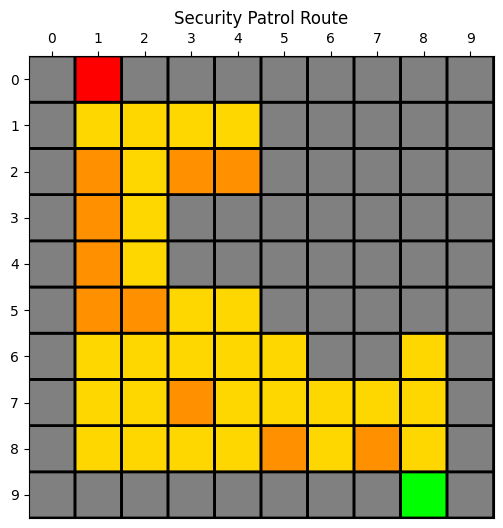

In [43]:
map = MapGenerator(seed=SEED)
map.generate_map()
map.visualize()

### <a id="rl_why"></a> **6.3 Justification for Algorithm Choice** (Q Learning vs SARSA)

So, to fulfill the requirements of the "Quick Scan" and "Deep Scan" protocols, the algorithms must optimize different success criteria within the industrial environment. The reward structure penalizes collisions (−5) and rewards massively(+500) for a Perfect run (visiting all 10 nodes). Based on Temporal Difference learning theory, we hypothesize that Q-Learning (off-policy) and SARSA (on-policy) naturally map to our two protocols.

1. Q-Learning (Off-Policy)
    * Mechanism: Q-Learning updates its value estimates based on the maximum possible future reward, acting entirely independent of the agent's current exploratory actions.
    * Advantage: This assumes perfect future execution, so, it is mathematically unbothered by the risk of random collisions. It will greedily pursue the massive (+500) bonus, choosing an exhaustive, complex route to hit every single inspection node.
    * Disadvantage: It is aggressively optimistic. By ignoring the inherent risks of a tight, hazardous layout, it may plot routes with zero safety margins.

2. SARSA (On-Policy)**
    * Mechanism: SARSA incorporates the agent's actual next action—including its own random exploration rate (epsilon -greedy)—into its value updates.
    * Advantage: It is inherently risk-averse. Because SARSA "knows" its own randomness might cause it to crash into a wall and suffer a (-5) penalty It should naturally learn a safer and more direct route to the exit, inspite of securing a partial reward without taking damage.
    * Disadvantage: It will likely result in sub-optimal data collection, sacrificing the validation of several peripheral nodes to ensure a safe, rapid extraction.

##### **Hypothesis**
According to our hypothesis, Q-Learning is ideal for the Deep Scan, where scans all possibl locations and do validation checks (hitting all nodes), prioritizing rewards over route simplicity. And SARSA perfectly models the Quick Scan, prioritizing a fast, physically secure exit over exhaustive checks.

**Hyperparameter Optimization and Selection**
Identical hyperparameters were explicitly chosen for both Q-Learning and SARSA to ensure that any difference in their behavior during inference comes from how the algorithms work mathematically, not from different settings.
1. Learning Rate (alpha = 0.1) - It determines to which extend the newly acquired information overrides existing Q-table values.
    * Justification - To ensure stable convergence. In Q Learning, this allows slow construction of routes. For SARSA, this prevents from breaking an established safe route and smoothly integrated into the policy.
2. Discount Factor (gamma = 0.95) - It dictates the weight of future rewards versus immediate rewards.
    * Justification: High gamma is absolute nessacity for our hypothesis. Without this, Q learning would never be able to see the massive rewards of +500 at end and would not do the deep scan. While for SARSA, this ensures the agent evaluates long-term cumulative risk across the long journey, it opts for a shorter, safer route for "Quick Scan.
3. Initial Exploration Rate (epsilon = 1.0) - Its the probability of taking a random action.
    * Justification: Starting 100% randomn is mandatory. As the agent spawns with a completely empty Q-table ([0.0, 0.0, 0.0, 0.0]). To discover the 10 randomized Inspection Nodes scattered across the facility matrix, it must begin with pure, unguided exploration.
4. Epsilon Decay Rate (ep_decay = 0.999) - It's speed from random exploration to strict policy exploitation.
    * Justification: It is choosen to be slow because, Q-Learning requires more time to accidentally stumble upon all 10 nodes to do the Deep Scan, while SARSA needs this to experience enough wall collisions to learn its low risk route for quick scan.
5.  Minimum Epsilon (min_ep = 0.01) - It determines ablity to explore.
    * Justification: It ensures the agents never completely stop exploring, preventing them from getting trapped in local optima.

----------------------------------------------------------------------------------------------

### <a id="#rl_imp"></a> **6.4 Implementation**

In [ ]:
# rl_utils.py

import numpy as np
import matplotlib.pyplot as pt

def visualize_training(rewards, time_taken, title, save_path): 
    window = 10
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    else:
        moving_avg = rewards
    mins = int(time_taken // 60)
    secs = time_taken % 60
    pt.figure(figsize=(10,8))
    pt.plot(rewards, alpha=0.3, color='gray', label='Reward')
    pt.plot(range(window-1, len(rewards)), moving_avg, color='blue', linewidth=2, label=f'{window}-Ep Moving Avg')
    pt.title(f"{title}\nTotal Training Time: {mins}m {secs:.5f}s", fontsize=14, fontweight='bold')
    pt.xlabel("Episodes", fontsize=12)
    pt.ylabel("Total Reward", fontsize=12)
    pt.legend()
    pt.grid(True, linestyle='--', alpha=0.6)
    pt.savefig(save_path, dpi=300)
    pt.close()
    print("\nTraining graph saved")

def visulazie_comparison(q_history, s_history, q_time, s_time, plot_path):
    window = 100
    q_avg = np.convolve(q_history, np.ones(window)/window, mode='valid')
    s_avg = np.convolve(s_history, np.ones(window)/window, mode='valid')
    
    fig, (ax1, ax2) = pt.subplots(1, 2, figsize=(16, 7))
    # Plot 1: Learning Convergence
    ax1.plot(range(window-1, len(q_history)), q_avg, label='Q-Learning', color='blue', linewidth=2)
    ax1.plot(range(window-1, len(q_history)), s_avg, label='SARSA', color='orange', linewidth=2)
    ax1.set_title("Learning Convergence (Moving Avg)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Episodes")
    ax1.set_ylabel("Total Reward")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Training Time Bar Chart
    algorithms = ['Q-Learning', 'SARSA']
    times = [q_time, s_time]
    bars = ax2.bar(algorithms, times, color=['blue', 'orange'], alpha=0.8)
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.5f}s', ha='center', va='bottom', fontweight='bold')
    ax2.set_title("Total Training Time (10k Episodes)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Seconds")
    ax2.set_ylim(0, max(times) * 1.2)
    
    pt.tight_layout()
    pt.savefig(plot_path, dpi=300)
    print(f"\nComparison graph saved to {plot_path}")

In [ ]:
# rl_models.py

import os
import json
import random
import collections
import numpy as np

class RLModels:
    def __init__(self, action_space, model_dir, alpha=0.1, gamma=0.95, ep=1.0, ep_decay=0.999):
        self.action_space = action_space
        self.alpha     = alpha 
        self.gamma     = gamma 
        self.ep        = ep 
        self.ep_decay  = ep_decay
        self.model_dir = model_dir
        self.min_ep    = 0.01
        self.qtable    = collections.defaultdict(lambda: [0.0, 0.0, 0.0, 0.0]) 

    def choose_action(self, state):
        if random.random() < self.ep:
            return random.choice(self.action_space) 
        else:
            return np.argmax(self.qtable[state]) 

    def decay_ep(self): 
        self.ep = max(self.min_ep, self.ep * self.ep_decay)

    def save_model(self, name): 
        serializable_qtable = {str(k): v for k, v in self.qtable.items()}
        if name is "q":
            model_path = os.path.join(self.model_dir, "q_brain.json")
        else:
            model_path = os.path.join(self.model_dir, "sarsa_brain.json")
        with open(model_path, 'w') as f:
            json.dump(serializable_qtable, f)
        print(f"Model saved to {model_path}")

class QLearning(RLModels):
    def learn(self, state, action, reward, next_state, complete):
        curr_q = self.qtable[state][action]
        target = reward if complete else reward + self.gamma * max(self.qtable[next_state])
        self.qtable[state][action] += self.alpha * (target - curr_q)

class SARSA(RLModels):
    def learn(self, state, action, reward, next_state, next_action, complete):
        curr_q = self.qtable[state][action]
        target = reward if complete else reward + self.gamma * self.qtable[next_state][next_action]
        self.qtable[state][action] += self.alpha * (target - curr_q)

In [ ]:
# train_rl_models.py

import os
import time

class RLTraining:
    def __init__(self,episodes, seed, plot_dir, model_dir):
        self.episodes = episodes
        self.seed = seed
        self.plot_dir = plot_dir
        self.model_dir = model_dir
        self.model_classes = {"q": QLearning, "sarsa": SARSA}

    def make_env(self):  # Env
        gen = MapGenerator(seed=self.seed)
        grid, spawners = gen.generate_map()
        print(f"Spawner Locations: {spawners}")
        gen.visualize()
        return EnvMap(grid, spawners, gen.entry_node, gen.exit_node)

    def run_model(self, name): 
        ModelClass = self.model_classes[name]
        env   = self.make_env()
        model = ModelClass(action_space=env.action_space, model_dir=self.model_dir)
        
        print(f"\nTraining {name}........")
        rewards = []
        start_time = time.time()
        for _ in range(self.episodes):
            state  = env.reset()
            action = model.choose_action(state)
            total_reward = 0
            complete = False
            while not complete:
                next_state, reward, complete = env.step_scoring(action) 
                next_action = model.choose_action(next_state) 
                if name == "sarsa":
                    model.learn(state, action, reward, next_state, next_action, complete) 
                else:
                    model.learn(state, action, reward, next_state, complete) 
                state = next_state
                action = next_action
                total_reward += reward
            model.decay_ep()
            rewards.append(total_reward)
        end_time = time.time()
        total_time = end_time - start_time
        model.save_model(name)
        print(f"{name} Training finished in {total_time:.5f}s")
        plot_path = os.path.join(self.plot_dir, f"{name}_training_plot.jpeg")
        visualize_training(rewards, total_time, f"{name.upper()} Model", plot_path)
        return rewards, total_time

    def train_rl_models(self): 
        q_history, q_time = self.run_model("q")
        s_history, s_time = self.run_model("sarsa")
        plot_path = os.path.join(self.plot_dir, "rl_model_comparison.jpeg")
        visulazie_comparison(q_history, s_history, q_time, s_time, plot_path)
        return {"Q-Learning": q_time, "SARSA": s_time}


In [ ]:
### File: rl_inference.py

import json
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
from pathlib import Path



class RLInference:
    MOVES = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

    def __init__(self, model_dir, qtable_file):
        model_dir     = Path(model_dir)
        raw           = json.loads((model_dir / qtable_file).read_text())
        self.qtable   = self.parse_qtable(raw)
        print(f"Q-table loaded: {qtable_file} ({len(self.qtable)} states)")

    @staticmethod
    def parse_qtable(raw_dict):
        parsed = {}
        for k, v in raw_dict.items():
            try:
                state = tuple(map(int, k.strip("()").split(',')))
                parsed[state] = v
            except:
                continue
        return parsed

    def run(self, env_map, animate, gif_path):
        t0 = time.perf_counter()
        current_node = env_map.entry_node
        visited      = 0
        steps        = 0
        rewards      = 0
        path         = [(current_node, visited)]

        while current_node != env_map.exit_node and steps < 250:
            steps   += 1
            state    = (current_node[0], current_node[1], visited)
            q_values = self.qtable.get(state)
            action   = int(np.argmax(q_values)) if q_values is not None else np.random.randint(0, 4)
            dy, dx = self.MOVES[action]
            nr, nc = current_node[0] + dy, current_node[1] + dx
            if nr < 0 or nr >= 10 or nc < 0 or nc >= 10 or env_map.grid[nr, nc] == 0:
                rewards -= 5
                continue
            current_node = (nr, nc)
            if current_node in env_map.spawners:
                idx = env_map.spawners.index(current_node)
                if not (visited & (1 << idx)):
                    visited |= (1 << idx)
                    rewards += 50
            if current_node == env_map.exit_node:
                if visited == (1 << len(env_map.spawners)) - 1:
                    rewards += 500
                else:
                    missed   = len(env_map.spawners) - bin(visited).count("1")
                    rewards += max(0, 100 - (missed * 10))
            else:
                rewards -= 1
            path.append((current_node, visited))
        if animate:
            animate_agent(env_map, path, gif_path)
        elapsed = time.perf_counter() - t0
        print(f"[RL] {steps} steps | reward: {rewards} | elapsed: {elapsed:.4f}s")
        return [p[0] for p in path], rewards, elapsed
    

def animate_agent(env_map, path, gif_path):
    cmap = ListedColormap(['#808080', '#FFD700', "#FF9100", '#FF0000', '#00FF00'])
    fig, ax = plt.subplots(figsize=(6, 6))

    vis_grid = np.copy(env_map.grid)
    for r, c in env_map.spawners:
        vis_grid[r, c] = 2
    vis_grid[env_map.entry_node] = 3
    vis_grid[env_map.exit_node]  = 4

    ax.pcolor(vis_grid[::-1], cmap=cmap, edgecolors='black', linewidths=2)
    ax.set_xticks(np.arange(0.5, 10.5, 1));  ax.set_xticklabels(range(10))
    ax.set_yticks(np.arange(0.5, 10.5, 1));  ax.set_yticklabels(reversed(range(10)))
    ax.xaxis.tick_top()

    ims = []
    for step_idx, (node, visited) in enumerate(path):
        x = node[1] + 0.5
        y = (9 - node[0]) + 0.5
        circle, = ax.plot(x, y, marker='o', color='#0000FF', markersize=18, animated=True)
        title   = ax.text(
            0.5, 1.05,
            f"Step {step_idx+1} | Visited: {bin(visited).count('1')}/10",
            transform=ax.transAxes, ha="center",
            fontsize=14, fontweight='bold', animated=True
        )
        ims.append([circle, title])

    ani = animation.ArtistAnimation(fig, ims, interval=500, blit=True)
    ani.save(gif_path, writer='pillow')
    plt.close()

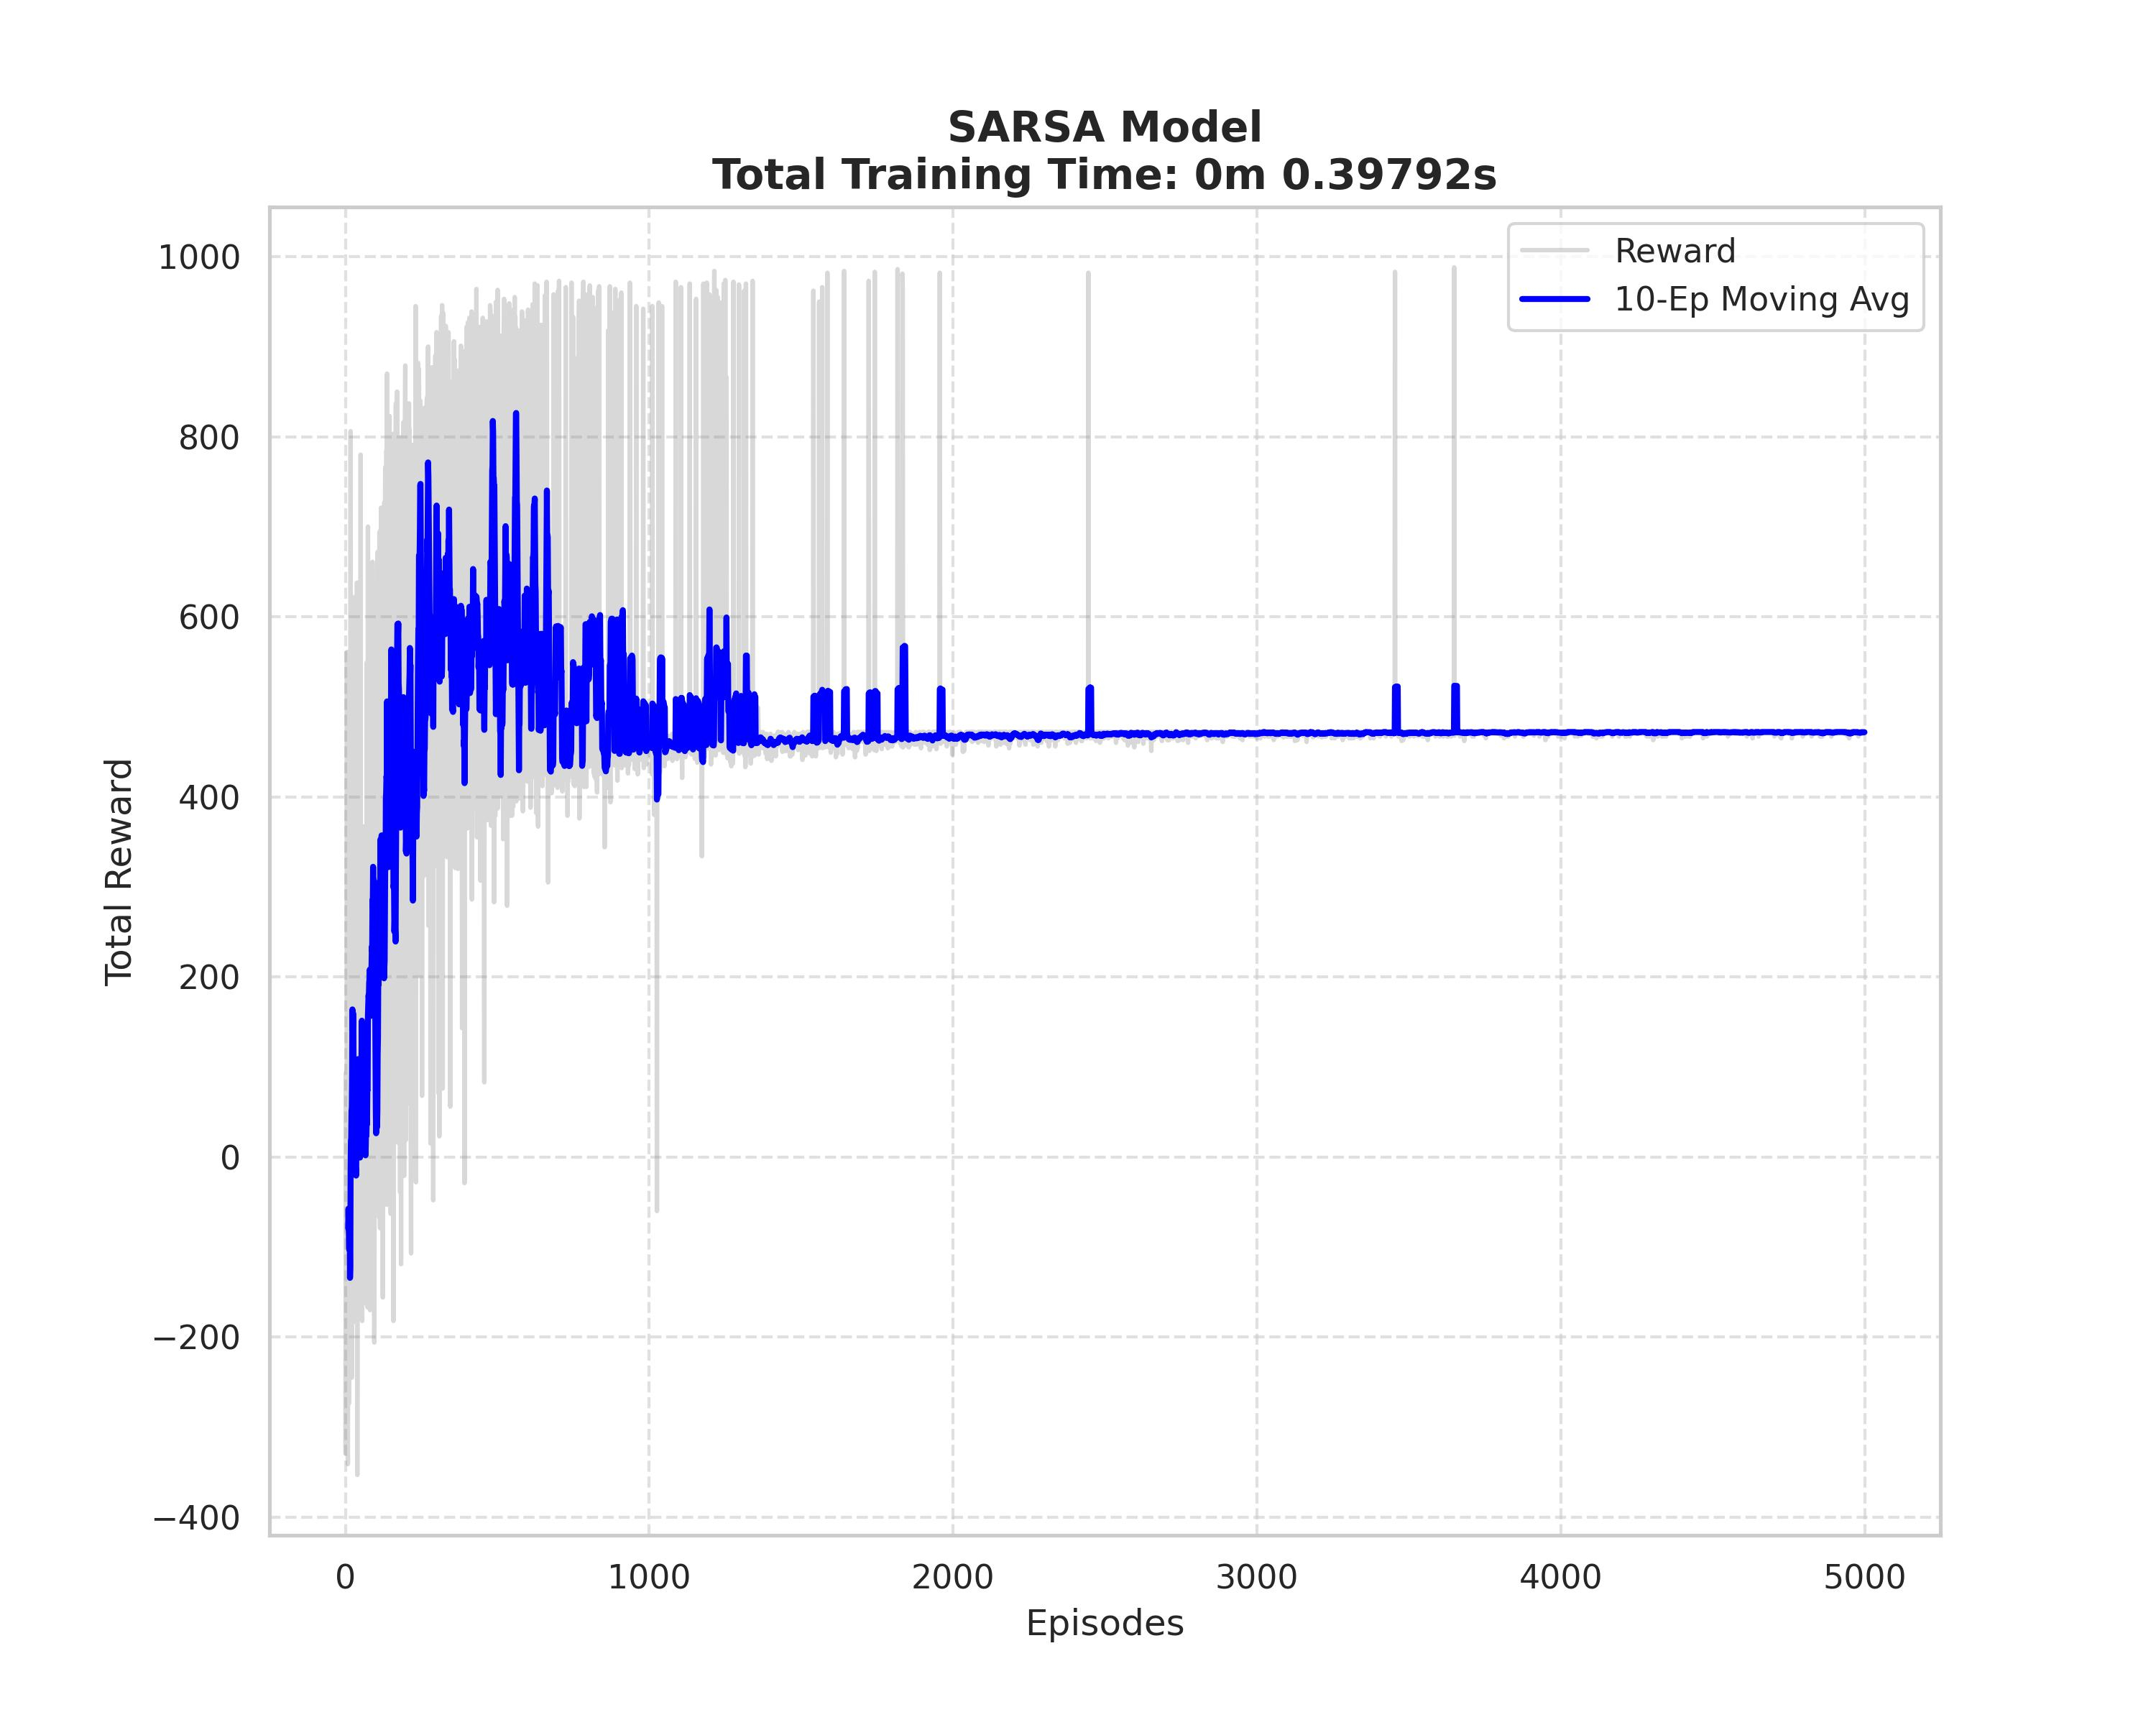

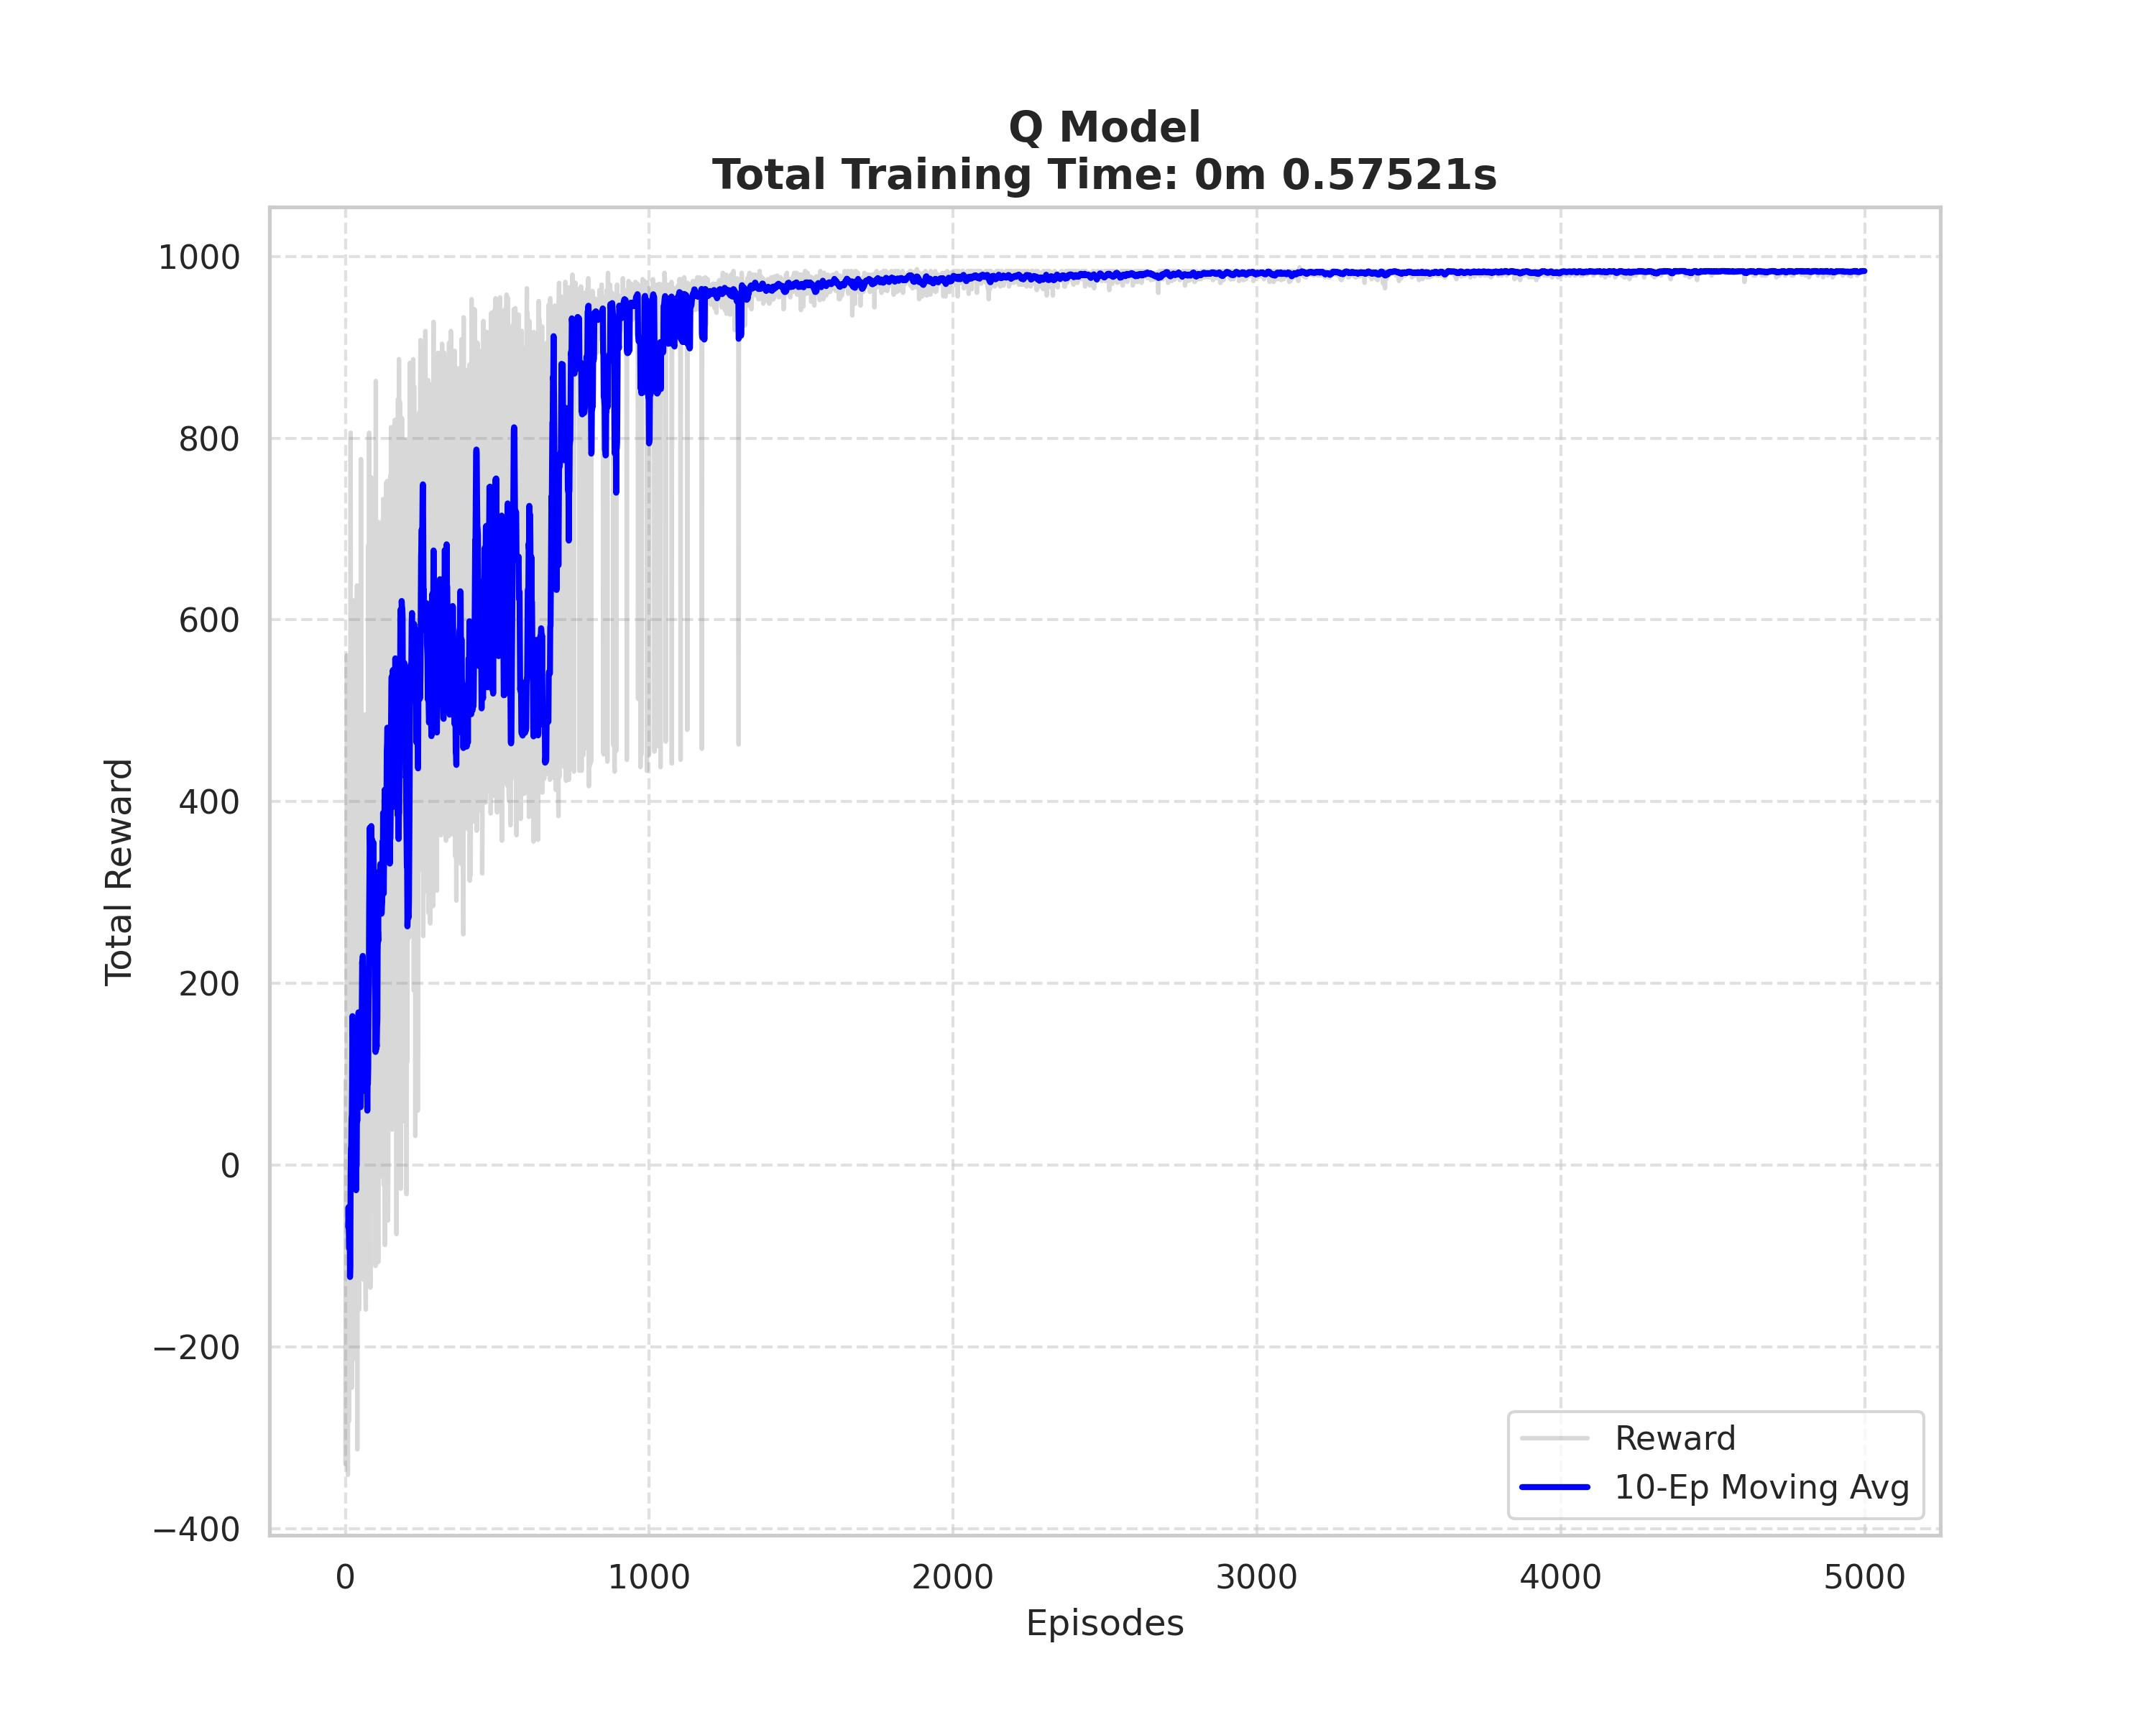

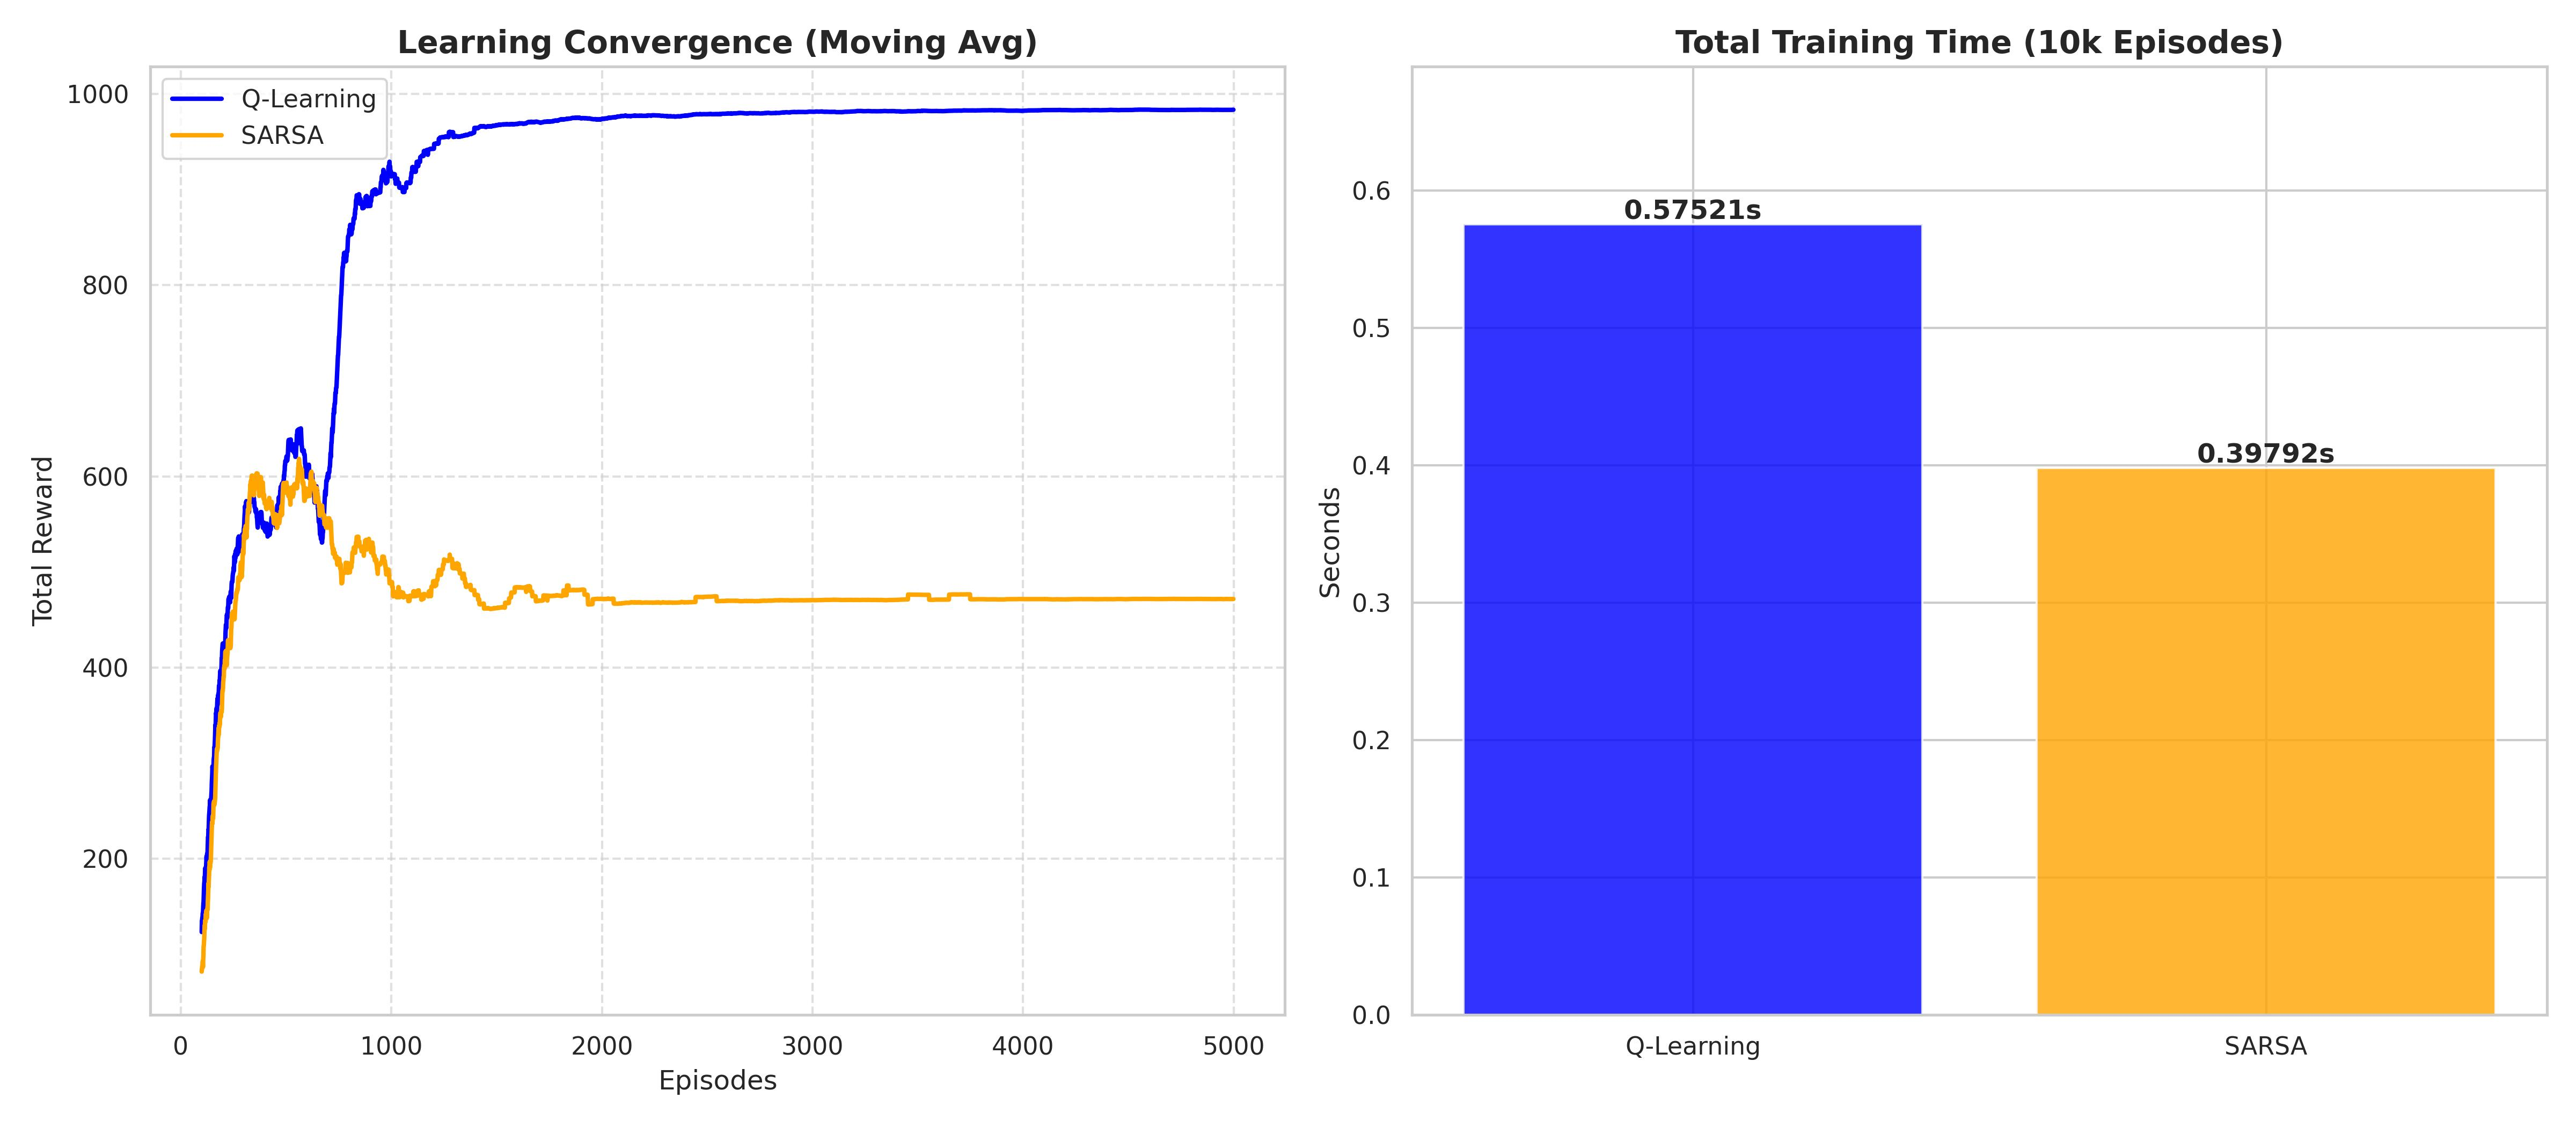

In [ ]:
from IPython.display import Image, display

# REINFORCEMENT LEARNING PIPELINE
print("REINFORCEMENT LEARNING MODELS TRAINING......")
rl_trainer = RLTraining(episodes=5000, seed=SEED, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
rl_trainer.train_rl_models()
print("REINFORCEMENT LEARNING MODELS TRAINING COMPLETE")

display(Image(filename='PLOTS/sarsa_training_plot.jpeg'))
display(Image(filename='PLOTS/q_training_plot.jpeg'))
display(Image(filename='PLOTS/rl_model_comparison.jpeg'))

### <a id="rl_comp"></a> **6.5 Comparative Training Analysis**

Following the execution of the training loop over 5,000 episodes, the learning dynamics and computational efficiency of both agents were recorded. The plots do provide early indicators of how the agents responded to the environment's penalty and reward structure.

1. Both algorithms exhibit a sharp, nearly identical rise in total reward during the initial exploration phase. This occurs because (epsilon) is at its highest, allowing both agents to organically discover the exit and accumulate baseline node rewards.

2. Q-Learning continues to climb aggressively, reaching a near-maximum reward and then plateauing between episodes 1000 and 1500, as it assumes perfect future reward and ignores exploration risk, yielding a high-reward optimized policy.

3. SARSA peaks early near 600, then experiences a significant drop and fluctuation before stabilizing at a plateau just below the 500-point mark. As the exploration rate decays, SARSA continually experiences wall collisions, so it internalizes this risk and abandons the +500 perfect-run path as too dangerous. 

4. The time discrepancy is not due to computational complexity, but due to the physical length of their learned policies. Q-Learning's policy requires it to stay in the maze longer per episode to physically touch every single inspection node, while SARSA learns to exit the maze much earlier.

Note - While these are training metrics, but this shows our earlier theoretical assumptions of high-reward, longer-duration profile of Q-Learning for DEEP SCAN and lower-reward, faster-computation profile of SARSA for QUICK SCAN

----------------------------------------------------------------------------------------------

---

---
## <a id="infer"></a> **7. Combined Inference**
---

### <a id="pipe"></a> **7.1 Pipeline Explaination**



----------------------------------------------------------------------------------------------

now for report_pipeline.py

1. We'll run the inference and get the plots for all individual models and overall report
2. finally We create a report table df1 with these columns:
    * Ground Truth (this will be taken from spnwer)
    * Does it have airborne_status (Ground_truth)
    * Does it have remote_override_flag (ground_truth)
    * SL_answer
    * SL_conf
    * Does_match with ground_truth with more than 98% conf (if yes, level 1 cleared)
         - ex - If SL AGV (fly or no fly) matches with ground_truth AGV and level 1 check complete
    * Does it mathces override_flag or airborne_status (as Sl will divide into 7 classfication, so we'll know if it is flaged with these) (if yes level 2 is cleared)
        - ex - if SL AGV (fly) means Airbone_status(from ground truth) should be true, if not level 2 fails. same for robotic_arm in overide case.
    * USL_answer
    * USL_conf
    * Does_match with ground_truth with more than 95% conf (if yes, level 3 cleared)
    * Level_cleared (1 or 2 or 3)
3. Another table df2 where I run multiple runs with different combinations of models (We'll be specfy which model we are choosing for SL, usl, RL, at start of every run)
    * USL_model
    * SL_model
    * RL_model
    * Points_level_cleared (if all 3 level is cleared than 3 points, if only 2 level are cleared than only 2 points and same for 1, so max point is 30, 3x10 10, locations)
    * Total rewards collected by RL
    * Time taken by RL model to complete (this will be)
4. We have to see (visualize) the arrow navigating rl env.
5. Rows will be 10 locations which is set by spanwer for df1, it also collect 100 rows and 100 images


### <a id="imp"></a> **7.2 Implementation**

# Inference

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from collections import Counter

SL_MODELS  = ["rf_model.pkl",    "svm_model.pkl"]
USL_MODELS = [("gmm", "gmm_model.pkl"), ("dec", "dec_model.pt")]
RL_MODELS  = ["q_brain.json",    "sarsa_brain.json"]

def parse_label(label):
    if label.startswith("robotic_arm"):
        return "robotic_arm", label[12:]
    elif label.startswith("agv_unit"):
        return "agv_unit", label[9:]
    else:
        parts = label.split("_")
        return parts[0], "_".join(parts[1:])

def evaluate_levels(gt, air, override, sl_ans, sl_conf, usl_ans, usl_conf):
    gt_base, _          = parse_label(gt)
    sl_base, sl_attrs   = parse_label(sl_ans)
    l1 = (sl_base == gt_base) and (sl_conf > 0.98)
    fly_ok      = ("fly" in sl_attrs) if air else ("non_fly" in sl_attrs or "fly" not in sl_attrs)
    override_ok = ("override" in sl_attrs) if override else ("non_override" in sl_attrs or "override" not in sl_attrs)
    l2 = fly_ok and override_ok
    l3 = (usl_ans == gt) and (usl_conf > 0.95)
    return l1, l2, l3, int(l1) + int(l2) + int(l3)

def aggregate_usl_result(result, class_names):
    majority_cluster = Counter(result.predictions).most_common(1)[0][0]
    majority_mask    = result.predictions == majority_cluster
    return class_names[majority_cluster], float(np.mean(result.confidences[majority_mask]))

def combo_tag(sl_file, usl_name, rl_file):
    sl = sl_file.replace(".pkl", "").replace(".pt", "")
    rl = rl_file.replace(".json", "")
    return f"{sl}__{usl_name}__{rl}"

In [ ]:
Path("RESULTS").mkdir(exist_ok=True)
print("[1] Initializing Data Spawner and Environments...")
spawner = DataSpawner(csv_path="DATA/SENSOR_STATS.csv", image_dir="DATA/DATASET")
map_gen = MapGenerator(seed=47)
map_gen.generate_map()

# Consolidated containers
all_df1_rows = []
df2_rows = []

total_pipeline_time = 0.0
combo_count = 0

# Grid Search: 8 combinations
for sl_file, (usl_name, usl_file), rl_file in product(SL_MODELS, USL_MODELS, RL_MODELS):
    combo_count += 1
    tag = combo_tag(sl_file, usl_name, rl_file)
    print(f"\n[Combo {combo_count}/8] Running: {tag}")

    # Load models
    sl_engine  = SLInference(model_dir="MODELS",  model_file=sl_file)
    usl_engine = USLInference(model_dir="MODELS", pipeline_name=usl_name, seed=47)
    rl_engine  = RLInference(model_dir="MODELS",  qtable_file=rl_file)

    combo_total_time = 0.0
    level_cleared_sum = 0

    # --- SL & USL Evaluation ---
    for loc_id in range(10):
        target_class, sampled_rows_df, images_paths, gt_air, gt_override = spawner.get_payload(loc_id)

        sl_ans, sl_conf, sl_time = sl_engine.run(sampled_rows_df.to_dict('records'))
        usl_result = usl_engine.run(images_paths)
        usl_ans, usl_conf = aggregate_usl_result(usl_result, spawner.classes)
        usl_time = usl_result.elapsed_sec

        combo_total_time += sl_time + usl_time

        l1, l2, l3, lvl = evaluate_levels(
            target_class, gt_air, gt_override,
            sl_ans, sl_conf, usl_ans, usl_conf
        )
        level_cleared_sum += lvl

        # Append to master DF1 list with model identifiers
        all_df1_rows.append({
            "Location_ID": loc_id,
            "Ground_Truth": target_class, "Airborne_(GT)": gt_air, "Override_(GT)": gt_override,
            "SL_Answer": sl_ans, "SL_Conf": sl_conf,
            "USL_Answer": usl_ans, "USL_Conf": usl_conf,
            "L1_Cleared": l1, "L2_Cleared": l2, "L3_Cleared": l3, "Level_Cleared": lvl,
            "USL_Model": usl_file, "SL_Model": sl_file, "RL_Model": rl_file
        })

    # --- RL Navigation ---
    gif_path = f"RESULTS/rl_animation__{tag}.gif"
    path, reward, rl_time = rl_engine.run(map_gen, animate=True, gif_path=gif_path)

    combo_total_time += rl_time
    total_pipeline_time += combo_total_time

    # Append to DF2 list
    df2_rows.append({
        "SL_Model": sl_file,
        "USL_Model": usl_file,
        "RL_Model": rl_file,
        "Points_Level_Cleared": level_cleared_sum,
        "Total_Rewards_Collected": round(reward, 4),
        "Time_Taken_RL": round(rl_time, 4),
        "Total_Time": round(combo_total_time, 4)
    })

# --- SAVE CONSOLIDATED DF1 ---
df1 = pd.DataFrame(all_df1_rows)
df1_cols = [
    "Location_ID", "Ground_Truth", "Airborne_(GT)", "Override_(GT)", 
    "SL_Answer", "SL_Conf", "USL_Answer", "USL_Conf", 
    "L1_Cleared", "L2_Cleared", "L3_Cleared", "Level_Cleared", 
    "USL_Model", "SL_Model", "RL_Model"
]
df1 = df1[df1_cols]
df1.to_csv("RESULTS/df1_all_combinations.csv", index=False)

# --- SAVE CONSOLIDATED DF2 ---
df2 = pd.DataFrame(df2_rows)
df2_cols = [
    "SL_Model", "USL_Model", "RL_Model", 
    "Points_Level_Cleared", "Total_Rewards_Collected", 
    "Time_Taken_RL", "Total_Time"
]
df2 = df2[df2_cols]
df2.to_csv("RESULTS/df2_all_combinations.csv", index=False)

print(f"\n{'='*60}")
print(f"Grid Search Complete. Results saved in 'RESULTS/' folder.")
print(f"Total Combined Rows in DF1: {len(df1)}")
print(f"Animations Generated: {combo_count}")
print(f"Grand Total Pipeline Time: {total_pipeline_time:.2f}s")
print(f"{'='*60}")

In [ ]:
df2 = pd.read_csv("RESULTS/df1_all_combinations.csv")
df2.head (10)

In [ ]:
df1 = pd.read_csv("RESULTS/df2_all_combinations.csv")
df1.head (30)

,SL_Model,USL_Model,RL_Model,Points_Level_Cleared,Total_Rewards_Collected,Time_Taken_RL,Total_Time
0,rf_model.pkl,gmm_model.pkl,q_brain.json,21,975,1.4318,4.1898
1,rf_model.pkl,gmm_model.pkl,sarsa_brain.json,21,465,0.9484,2.4253
2,rf_model.pkl,dec_model.pt,q_brain.json,22,975,1.3717,2.9739
3,rf_model.pkl,dec_model.pt,sarsa_brain.json,22,465,0.8969,2.6890
4,svm_model.pkl,gmm_model.pkl,q_brain.json,19,975,1.4284,3.4463
5,svm_model.pkl,gmm_model.pkl,sarsa_brain.json,19,465,0.8982,2.9460
6,svm_model.pkl,dec_model.pt,q_brain.json,20,975,1.3884,3.4314
7,svm_model.pkl,dec_model.pt,sarsa_brain.json,20,465,0.8877,2.8587


### <a id="con"></a> **7.3 Conclusion**



---
# END OF FILE
---